# Redundancy in hidden Transformer layers

In [1]:
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
plt.style.use('ggplot')

cmaps = {
    'cosine': 'Reds', #'RdGy',
    'cka': 'Purples',
    'knn': 'Greens', # 'RdYlGn', #'coolwarm',
    'jacobian': 'RdBu',
}

In [2]:
def plot_heuristic(experiments, ax, res_per_exp=1, relative_layer_idx=False, heuristic='block-influence'):
    assert res_per_exp <= 3
    color_idx = -1
    start_layer_idx = 2
    for exp_name, exp_path in experiments.items():
        results = torch.load(exp_path)
        
        _scores = torch.stack(results[f'all-{heuristic}s']).mean(dim=1)
        n_samples, n_layers = _scores.shape
        color_idx += 1

        if relative_layer_idx:
            xaxis = (np.arange(n_layers) + 1) / n_layers
            ax.set_xlabel('Normalized depth')
        else:
            xaxis = np.arange(n_layers) + start_layer_idx - 1
            ax.set_xlabel('Layer')

        ax.plot(xaxis, _scores.mean(dim=0), label=exp_name, linestyle='-' if color_idx % res_per_exp == 0 else '--' if color_idx % res_per_exp == 1 else '-.', color=f'C{color_idx // res_per_exp}')
        ax.fill_between(xaxis, _scores.quantile(0.05, dim=0), _scores.quantile(0.95, dim=0), alpha=0.3, color=f'C{color_idx // res_per_exp}')
    

    ax.set(ylabel=f'{heuristic.capitalize()} score [$\mu$ and 90% CI]')
    ax.legend()
    return ax

def plot_block_influence(experiments, ax, res_per_exp=1, relative_layer_idx=False):
    assert res_per_exp <= 3
    color_idx = -1
    start_layer_idx = 2
    for exp_name, exp_path in experiments.items():
        results = torch.load(exp_path)
        if 'all-block-inferences' in results.keys():
            results['all-block-influences'] = results['all-block-inferences']
        
        bi_scores = torch.vstack(results['all-block-influences'])
        n_samples, n_layers = bi_scores.shape
        color_idx += 1

        if relative_layer_idx:
            xaxis = np.arange(n_layers) / n_layers
            ax.set_xlabel('Normalized depth')
        else:
            xaxis = np.arange(n_layers) + start_layer_idx - 1
            ax.set_xlabel('Layer')

        ax.plot(xaxis, bi_scores.mean(dim=0), label=exp_name, linestyle='-' if color_idx % res_per_exp == 0 else '--' if color_idx % res_per_exp == 1 else '-.', color=f'C{color_idx // res_per_exp}')
        ax.fill_between(xaxis, bi_scores.quantile(0.05, dim=0), bi_scores.quantile(0.95, dim=0), alpha=0.3, color=f'C{color_idx // res_per_exp}')
    

    ax.set(ylabel='Block Influence score [$\mu$ and 90% CI]')
    ax.legend()
    return ax

def plot_block_influence_with_multi(experiments, ax, res_per_exp=1, uncertainty=False):
    assert res_per_exp <= 3
    color_idx = -1
    start_layer_idx = 2
    for exp_name, exp_path in experiments.items():
        results = torch.load(exp_path)
        if 'all-block-inferences' in results.keys():
            results['all-block-influences'] = results['all-block-inferences']
        
        for _k in ['all-block-influences', 'all-knn-block-influences']:#, 'all-multi-block-influences']:
            bi_scores = torch.vstack(results[_k])
            n_samples, n_layers = bi_scores.shape
            color_idx += 1
            
            xaxis = np.arange(n_layers) / n_layers
            ax.plot(xaxis, bi_scores.mean(dim=0), label=exp_name + ' - ' + ('kNN-BI' if 'knn' in _k else 'knn-mBI' if 'multi' in _k else 'BI'), linestyle='-' if color_idx % res_per_exp == 0 else '--' if color_idx % res_per_exp == 1 else '-.', color=f'C{color_idx // res_per_exp}')
            if uncertainty:
                ax.fill_between(xaxis, bi_scores.quantile(0.05, dim=0), bi_scores.quantile(0.95, dim=0), alpha=0.3, color=f'C{color_idx // res_per_exp}')

    ax.set(xlabel='Relative layer index', ylabel='Block Influence score [$\mu$ and 90% CI]')
    ax.legend()
    return ax

def merge_results(experiments):
    for i, (exp_name, exp_path) in enumerate(experiments.items()):
        results = torch.load(exp_path)
        if i == 0:
            merged_results = results
        else:
            for k in merged_results['accuracy'].keys():
                for i in range(len(merged_results['accuracy'][k])):
                    try:
                        merged_results['accuracy'][k][i] += results['accuracy'][k][i]
                    except KeyError:
                        pass
                        
            merged_results['all-jacobian-batch-similarities'] += results['all-jacobian-batch-similarities']

    return merged_results

def get_rank(experiments, merge: bool = False, ranks: dict = {}, batch_size=None):
    if merge:
        results = {list(experiments.keys())[0]: merge_results(experiments)}
    else:
        results = {exp_name: torch.load(exp_path) for exp_name, exp_path in experiments.items()}

    for exp_name, res in results.items():
        _batch_size = int(exp_name.split("-")[-1]) if batch_size == 'varying' else batch_size

        num_layers = len(res['all-jacobian-batch-similarities'][0])
        rel_eigvals = torch.zeros((len(res['all-jacobian-batch-similarities']), num_layers))
        for i, _batch_sim_output in enumerate(res['all-jacobian-batch-similarities']):
            for j, (k, _batch_sim_output) in enumerate(_batch_sim_output.items()):
                if batch_size is not None:
                    _batch_sim_output = _batch_sim_output[:_batch_size, :_batch_size]

                eigvals, _ = torch.linalg.eigh(_batch_sim_output)
                rel_eigvals[i, j] = eigvals.max() / sum(eigvals)
        
        ranks[exp_name] = rel_eigvals
    
    return ranks

### Jacobian rank estimation

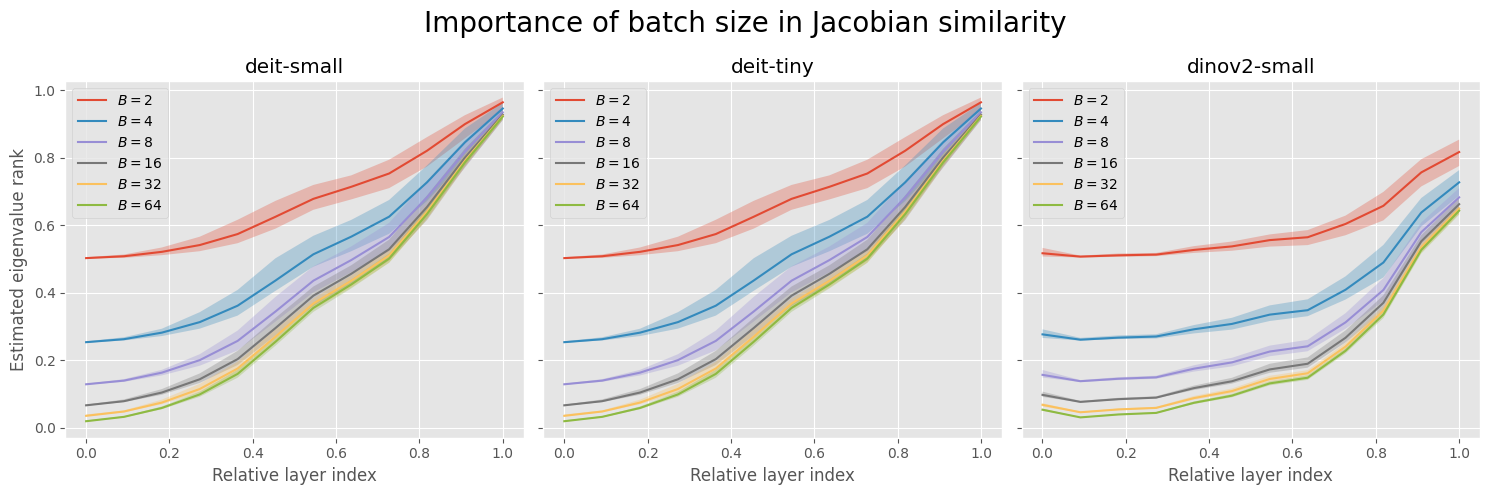

In [3]:
EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments")

_experiments = [
    {
        'deit-small-2' : EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-small-4' : EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-small-8' : EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-small-16': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-small-32': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-small-64': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    },
    {
        'deit-tiny-2' : EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-tiny-4' : EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-tiny-8' : EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-tiny-16': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-tiny-32': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-tiny-64': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    },
    {
        'dinov2-small-2': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
        'dinov2-small-4': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
        'dinov2-small-8': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
        'dinov2-small-16': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
        'dinov2-small-32': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
        'dinov2-small-64': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
    }
]

fig, axs = plt.subplots(1, len(_experiments), figsize=(int(len(_experiments) * 5), 5), sharey=True)
for i, experiments in enumerate(_experiments):
    ranks = get_rank(experiments, merge=False, ranks={}, batch_size='varying')
    for exp_name, rel_eigvals in ranks.items():
        num_layers = rel_eigvals.shape[1]
        if len(_experiments) == 1:
            axs.plot(np.linspace(0, 1, num_layers), rel_eigvals.mean(dim=0), label=f"$B={exp_name.split('-')[-1]}$")
            axs.fill_between(np.linspace(0, 1, num_layers), rel_eigvals.quantile(0.05, dim=0), rel_eigvals.quantile(0.95, dim=0), alpha=0.3)    
        else:
            axs[i].plot(np.linspace(0, 1, num_layers), rel_eigvals.mean(dim=0), label=f"$B={exp_name.split('-')[-1]}$")
            axs[i].fill_between(np.linspace(0, 1, num_layers), rel_eigvals.quantile(0.05, dim=0), rel_eigvals.quantile(0.95, dim=0), alpha=0.3)    

    if len(_experiments) == 1:
        axs.set_xlabel('Relative layer index', fontsize=16)
        axs.legend()
    else:
        axs[i].set_xlabel('Relative layer index')
        axs[i].set_title("-".join(list(experiments.keys())[0].split("-")[:2]))
        axs[i].legend()

if len(_experiments) == 1:
    axs.set_ylabel('Estimated eigenvalue rank', fontsize=16)
else:
    axs[0].set_ylabel('Estimated eigenvalue rank')
    fig.suptitle('Importance of batch size in Jacobian similarity', fontsize=20)
    
plt.tight_layout()
plt.show()

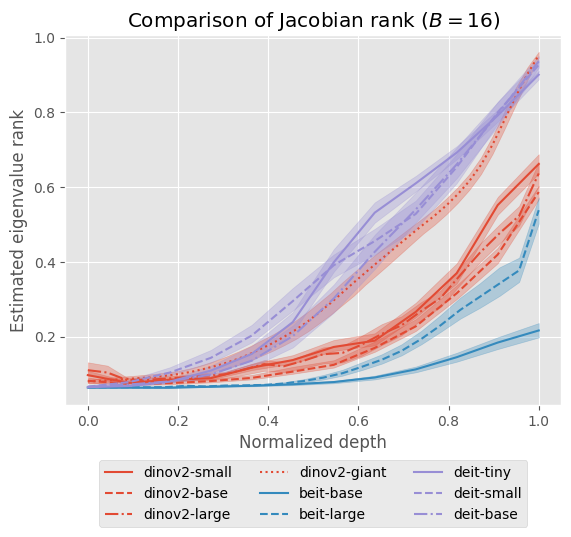

In [4]:
### DiNO
dino_experiments_small = {
    'dinov2-small': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
}
dino_experiments_base = {
    'dinov2-base': EXP_PATH / "vision/dinov2-base-imagenet1k-1-layer/iter0.pth",
    'dinov2-base-10': EXP_PATH / "vision/dinov2-base-imagenet1k-1-layer/iter10.pth",
    'dinov2-base-20': EXP_PATH / "vision/dinov2-base-imagenet1k-1-layer/iter20.pth",
    'dinov2-base-30': EXP_PATH / "vision/dinov2-base-imagenet1k-1-layer/iter30.pth",
    'dinov2-base-40': EXP_PATH / "vision/dinov2-base-imagenet1k-1-layer/iter40.pth",
}
dino_experiments_large = {
    'dinov2-large': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter0.pth",
    'dinov2-large-5': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter5.pth",
    'dinov2-large-10': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter10.pth",
    'dinov2-large-15': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter15.pth",
    'dinov2-large-20': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter20.pth",
    'dinov2-large-25': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter25.pth",
    'dinov2-large-30': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter30.pth",
    'dinov2-large-35': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter35.pth",
    'dinov2-large-40': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter40.pth",
    'dinov2-large-45': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter45.pth",
}
dino_experiments_giant = {
    'dinov2-giant': EXP_PATH / "vision/dinov2-giant-imagenet1k-1-layer/iter0.pth",
}
dino_experiments_giant.update({
    f'dinov2-giant-{i}': EXP_PATH / f"vision/dinov2-giant-imagenet1k-1-layer/iter{i}.pth" for i in range(1, 49)
})

ranks = get_rank(dino_experiments_small, ranks={}, batch_size=16)
ranks = get_rank(dino_experiments_base, merge=True, ranks=ranks, batch_size=16)
ranks = get_rank(dino_experiments_large, merge=True, ranks=ranks, batch_size=16)
ranks = get_rank(dino_experiments_giant, merge=True, ranks=ranks, batch_size=16)

# BEIT
beit_experiments_base = {
    'beit-base': EXP_PATH / "vision/beit-base/iter0.pth",
    'beit-base-15': EXP_PATH / "vision/beit-base/iter15.pth",
    'beit-base-35': EXP_PATH / "vision/beit-base/iter35.pth",
}
beit_experiments_large = {
    # 'beit-large': EXP_PATH / "vision/beit-large/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    'beit-large': EXP_PATH / "vision/beit-large/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=1_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    'beit-large-10': EXP_PATH / "vision/beit-large/iter10.pth",
    'beit-large-20': EXP_PATH / "vision/beit-large/iter20.pth",
    'beit-large-30': EXP_PATH / "vision/beit-large/iter30.pth",
    'beit-large-40': EXP_PATH / "vision/beit-large/iter40.pth",
}
ranks = get_rank(beit_experiments_base, ranks=ranks, merge=True, batch_size=16)
ranks = get_rank(beit_experiments_large, ranks=ranks, merge=True, batch_size=16)

### DEIT
deit_experiments = {
    'deit-tiny': EXP_PATH / "vision/deit-tiny/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    'deit-small': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
}
deit_experiments_base = {
    'deit-base': EXP_PATH / "vision/deit-base/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    'deit-base-20': EXP_PATH / "vision/deit-base/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=20_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    'deit-base-40': EXP_PATH / "vision/deit-base/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=40_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
}
ranks = get_rank(deit_experiments, ranks=ranks, batch_size=16)
ranks = get_rank(deit_experiments_base, ranks=ranks, merge=True, batch_size=16)

previous_exp = ''
color_idx = -1
linestyle_idx = 0
linestyles = ['-', '--', '-.', ':']

for exp_name, rel_eigvals in ranks.items():
    if exp_name.split("-")[0] in previous_exp:
        linestyle_idx += 1
    else:
        color_idx += 1
        linestyle_idx = 0

    num_layers = rel_eigvals.shape[1]
    plt.plot(np.linspace(0, 1, num_layers), rel_eigvals.mean(dim=0), label=exp_name, color=f'C{color_idx}', linestyle=linestyles[linestyle_idx])
    plt.fill_between(np.linspace(0, 1, num_layers), rel_eigvals.quantile(0.025, dim=0), rel_eigvals.quantile(0.975, dim=0), alpha=0.3, color=f'C{color_idx}')    
    
    previous_exp = exp_name

plt.xlabel('Normalized depth')
plt.ylabel('Estimated eigenvalue rank')
plt.legend(ncols=3, loc='lower center', bbox_to_anchor=(0.5, -0.35))
plt.title('Comparison of Jacobian rank ($B=16$)')
plt.show()

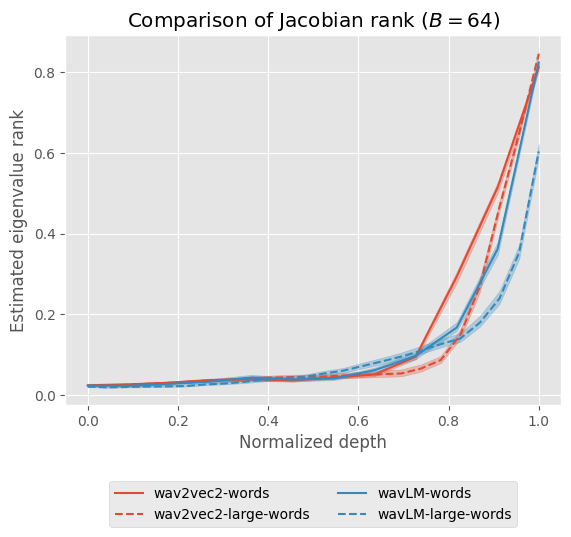

In [5]:
EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments")

batch_size = 64

### DiNO
wav2vec2_experiments = {
    'wav2vec2-words': EXP_PATH / "audio/wav2vec2-words/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence']_results.pth",
    'wav2vec2-large-words': EXP_PATH / "audio/wav2vec2-large-words/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence']_results.pth",
}
wavlm_experiments = {
    'wavLM-words': EXP_PATH / "audio/wavLM-words/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence']_results.pth",
    'wavLM-large-words': EXP_PATH / "audio/wavLM-large-words/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence']_results.pth",
}

ranks = get_rank(wav2vec2_experiments, ranks={}, batch_size=batch_size)
ranks = get_rank(wavlm_experiments, ranks=ranks, batch_size=batch_size)

previous_exp = ''
color_idx = -1
linestyle_idx = 0
linestyles = ['-', '--', '-.', ':']

for exp_name, rel_eigvals in ranks.items():
    if exp_name.split("-")[0] in previous_exp:
        linestyle_idx += 1
    else:
        color_idx += 1
        linestyle_idx = 0

    num_layers = rel_eigvals.shape[1]
    plt.plot(np.linspace(0, 1, num_layers), rel_eigvals.mean(dim=0), label=exp_name, color=f'C{color_idx}', linestyle=linestyles[linestyle_idx])
    plt.fill_between(np.linspace(0, 1, num_layers), rel_eigvals.quantile(0.025, dim=0), rel_eigvals.quantile(0.975, dim=0), alpha=0.3, color=f'C{color_idx}')    
    
    previous_exp = exp_name

plt.xlabel('Normalized depth')
plt.ylabel('Estimated eigenvalue rank')
plt.legend(ncols=2, loc='lower center', bbox_to_anchor=(0.5, -0.35))
plt.title(f'Comparison of Jacobian rank ($B={batch_size}$)')
plt.show()

### Similarity and pruning (audio)

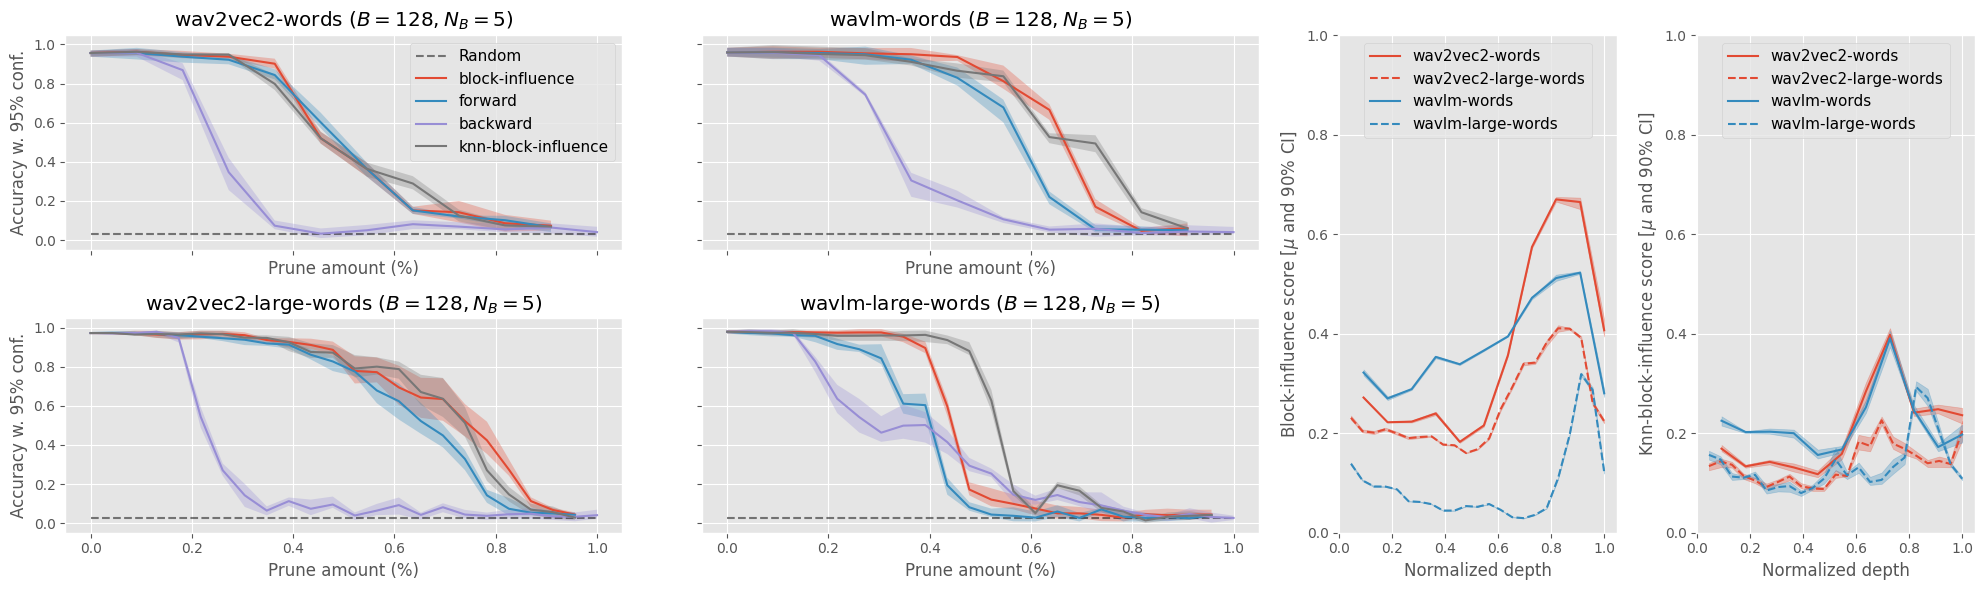

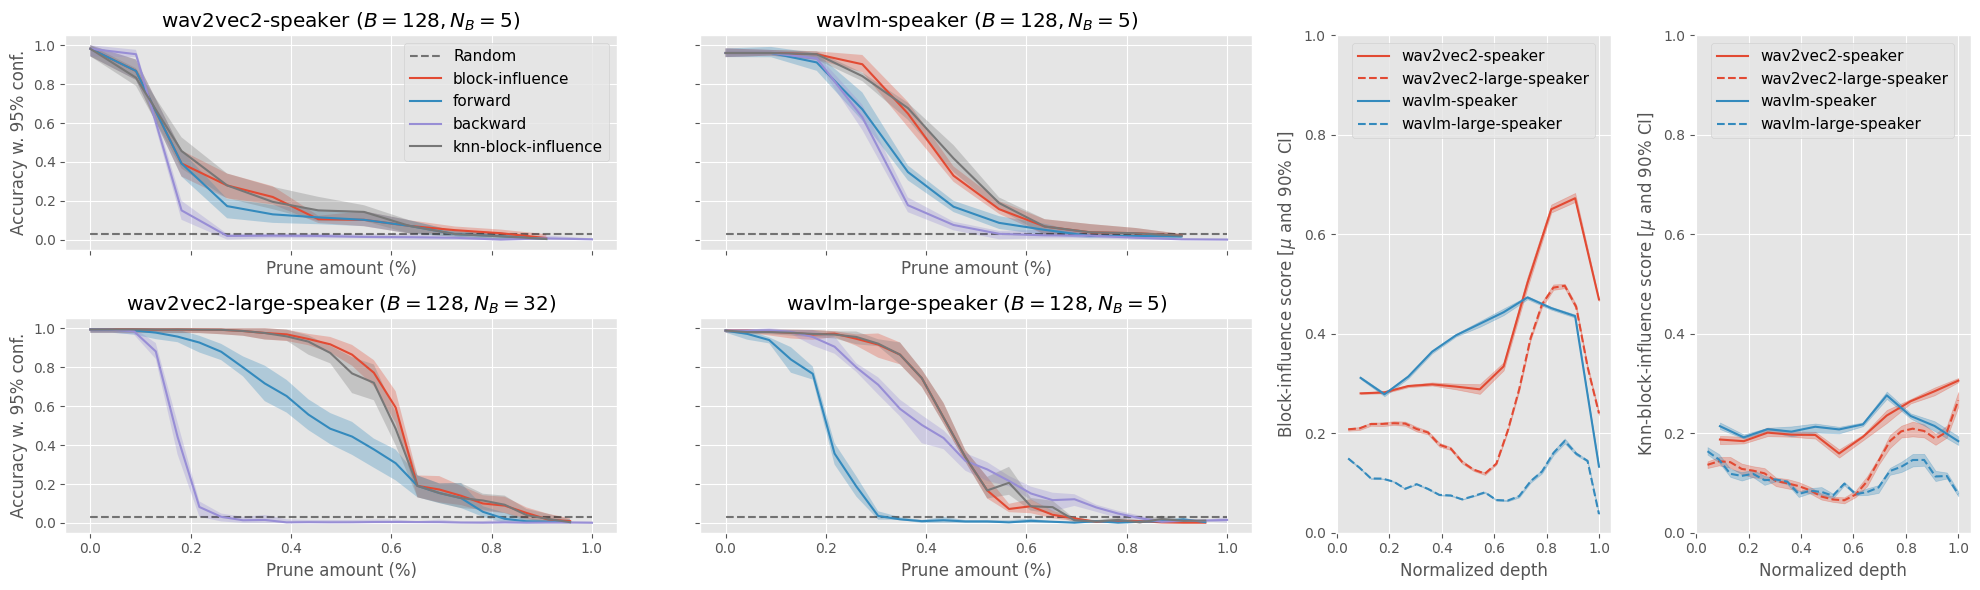

In [3]:
num_classes = 35
_conf = 95
_alpha = round((1 - _conf / 100), 2)

EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/pruning/adaptive")

for _ft_type in ['words', 'speaker']:

    fig, axs = plt.subplots(2, 2+2, figsize=(5*(2+2), 6), sharey=True, gridspec_kw={'width_ratios': [1, 1, 0.5, 0.5]}, sharex='col')
    for _row, size in enumerate(['', '-large']):
        all_results = {
            f'wav2vec2{size}-{_ft_type}': torch.load(EXP_PATH / f"audio/wav2vec2{size}-{_ft_type}/bs128_10iter_results.pth"),
            f'wavlm{size}-{_ft_type}': torch.load(EXP_PATH / f"audio/wavlm{size}-{_ft_type}/bs128_10iter_results.pth"),
        }

        num_layers = 24 if size == 'large' else 12

        for i, (exp_name, results) in enumerate(all_results.items()):
            n_batches = results['accuracy']['forward'][0].__len__()
            batch_size = results['all-block-influences'][0].shape[0]
            num_layers = results['all-block-influences'][0].shape[1] + 1

            axs[_row, i].hlines(1/num_classes, xmin=0, xmax=1, color='black', linestyle='--', alpha=0.5, label='Random')

            for pruning_strategy in ['block-influence', 'forward', 'backward', 'knn-block-influence']:
                mean_accs = {k: torch.tensor(v).mean().item() for k, v in results['accuracy'][pruning_strategy].items()}
                lower_accs = {k: torch.tensor(v).quantile(_alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
                upper_accs = {k: torch.tensor(v).quantile(1 - _alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}

                xaxis = np.arange(len(mean_accs.keys())) / (num_layers - 1) # 
                axs[_row, i].fill_between(xaxis, list(lower_accs.values()), list(upper_accs.values()), alpha=0.3)
                axs[_row, i].plot(xaxis, list(mean_accs.values()), label=pruning_strategy)

            axs[_row, i].set(xlabel='Prune amount (%)', title=f'{exp_name} ($B = {batch_size}, N_B = {n_batches}$)')
        axs[_row, 0].set(ylabel=f'Accuracy w. {_conf}% conf.')

    axs[0, 0].legend(loc='upper right', fontsize=11)

    # Plot block influence scores
    experiments = {
        f'wav2vec2-{_ft_type}': EXP_PATH / f"audio/wav2vec2-{_ft_type}/bs128_10iter_results.pth",
        f'wav2vec2-large-{_ft_type}': EXP_PATH / f"audio/wav2vec2-large-{_ft_type}/bs128_10iter_results.pth",
        f'wavlm-{_ft_type}': EXP_PATH / f"audio/wavlm-{_ft_type}/bs128_10iter_results.pth",
        f'wavlm-large-{_ft_type}': EXP_PATH / f"audio/wavlm-large-{_ft_type}/bs128_10iter_results.pth",
    }

    for _ax_idx in [2, 3]:
        gs = axs[0, 2].get_gridspec()
        # remove the underlying Axes
        for ax in axs[0:, _ax_idx]:
            ax.remove()
        axbig = fig.add_subplot(gs[0:, _ax_idx])
        plot_heuristic(experiments, axbig, res_per_exp=2, relative_layer_idx=True, heuristic='block-influence' if _ax_idx == 2 else 'knn-block-influence')
        axbig.set_ylim(0., 1.)
        axbig.legend(loc='upper center', fontsize=11)

    plt.tight_layout()
    plt.show()

In [5]:
def plot_similarity_matrix(ax, sims, _type, fig):
    # norm = TwoSlopeNorm(vmin=min(sims.min(), -1e-7), vcenter=0., vmax=max(sims.max(), 1e-7))
    # cbar = plt.cm.ScalarMappable(norm=norm, cmap=cmaps[_type])
    # ax.imshow(sims, cmap=cmaps[_type], norm=norm)
    img = ax.imshow(sims, cmap=cmaps[_type])
    fig.colorbar(img, ax=ax, fraction=0.04)
    ax.grid(False)

def plot_knn_similarities(ks, mutual_knn_within, mutual_knn_between, exp_name, offset):
    for i, _knn in enumerate([mutual_knn_within, mutual_knn_between]):
        for j, _k in enumerate(ks):
            plot_similarity_matrix(axs[i, j + offset], _knn[_k].mean(dim=0), 'knn')
            axs[i, j + offset].set_xlabel('Layer index') if i == 1 else axs[i, j + offset].set_title(f"$k$NN ($k={_k}$)")

In [6]:
import scipy.cluster.hierarchy as sch

def get_communities(mutual_K, linkage_type='average', num_clusters=None, distance_threshold=None, EXP_PATH: Path = None, filename='communities.pth', save=True) -> dict:
    ALL_COMMUNITIES = {}
    for _row, finetuning_type in enumerate(['words', 'speaker']):
        for idx, exp_name in enumerate(['wav2vec2', 'wav2vec2-large', 'wavLM', 'wavLM-large']):
            res = torch.load(EXP_PATH / f"audio/{exp_name}-{finetuning_type}/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth")
            sims = np.array([_res[mutual_K].numpy() for _res in res['all-mutual_knn-similarities']['between']]).mean(axis=0)

            linked = sch.linkage(sims, linkage_type)
            if num_clusters is not None:
                clusters = sch.fcluster(linked, num_clusters, criterion='maxclust')
            else:
                assert distance_threshold is not None, "Either num_clusters or distance_threshold must be specified"
                clusters = sch.fcluster(linked, distance_threshold, criterion='distance')
            
            communities = []
            for cluster_label in range(1, clusters.max() + 1):
                communities.append(set(np.where(clusters == cluster_label)[0]))

            ALL_COMMUNITIES[f"{exp_name}-{finetuning_type}"] = communities
    
    if save:
        torch.save(ALL_COMMUNITIES, EXP_PATH / filename)
    return ALL_COMMUNITIES

import scipy.cluster.hierarchy as sch

def plot_hierarhical_clusters(EXP_PATH, mutual_K, cluster_param, linkage_type, cluster_type):

    if cluster_type == 'num_clusters':
        ALL_COMMUNITIES = get_communities(mutual_K=mutual_K, num_clusters=cluster_param, linkage_type=linkage_type, EXP_PATH=EXP_PATH, save=False)
    else:
        ALL_COMMUNITIES = get_communities(mutual_K=mutual_K, distance_threshold=cluster_param, linkage_type=linkage_type, EXP_PATH=EXP_PATH, save=False)

    fig, axs = plt.subplots(2, 4, figsize=(20, 10), sharex='col')
    dendro_fig, dendro_axs = plt.subplots(2, 4, figsize=(20, 10))

    for _row, finetuning_type in enumerate(['words', 'speaker']):
        for idx, exp_name in enumerate(['wav2vec2', 'wav2vec2-large', 'wavLM', 'wavLM-large']):
            res = torch.load(EXP_PATH / f"audio/{exp_name}-{finetuning_type}/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth")

            sims = np.array([_res[mutual_K].numpy() for _res in res['all-mutual_knn-similarities']['between']]).mean(axis=0)
            linked = sch.linkage(sims, linkage_type)

            # add dendrogram to dendro_axs
            sch.dendrogram(linked, ax=dendro_axs[_row, idx], no_labels=False, orientation='top')
            dendro_axs[_row, idx].set_title(f"{exp_name}-{finetuning_type}")
            dendro_axs[_row, idx].set_xlabel('Layer index')
            dendro_axs[_row, idx].set_ylabel('Distance')
            dendro_axs[_row, idx].grid(False)

            img = axs[_row, idx].imshow(res['all-mutual_knn-similarities']['between'][0][K], cmap=cmaps['knn'])
            axs[_row, idx].grid(False)
            fig.colorbar(img, ax=axs[_row, idx], fraction=0.04)

            communities = ALL_COMMUNITIES[f"{exp_name}-{finetuning_type}"]
            for i in range(len(communities)):
                axs[_row, idx].hlines(y=min(communities[i]) - 0.5, xmin=min(communities[i]) - 0.5, xmax=max(communities[i]) + 0.5, color='C0')
                axs[_row, idx].hlines(y=max(communities[i]) + 0.5, xmin=min(communities[i]) - 0.5, xmax=max(communities[i]) + 0.5, color='C0')
                axs[_row, idx].vlines(x=min(communities[i]) - 0.5, ymin=min(communities[i]) - 0.5, ymax=max(communities[i]) + 0.5, color='C0')
                axs[_row, idx].vlines(x=max(communities[i]) + 0.5, ymin=min(communities[i]) - 0.5, ymax=max(communities[i]) + 0.5, color='C0')
            
            axs[_row, idx].set_title(f"{exp_name}-{finetuning_type}")
            axs[_row, idx].set_ylabel('Layer index')
            if _row == 0:
                axs[0, idx].set_xlabel('Layer index')

    fig.tight_layout()
    dendro_fig.tight_layout()
    plt.show()

In [27]:
# EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/similarities")

# for n_clusters in [2]: #2, 3, 4, 5, 6]:
#     ALL_COMMUNITIES = get_communities(num_clusters=n_clusters, filename=f'audio_communities_{n_clusters}clusters.pth')
#     print(ALL_COMMUNITIES['wav2vec2-words'])

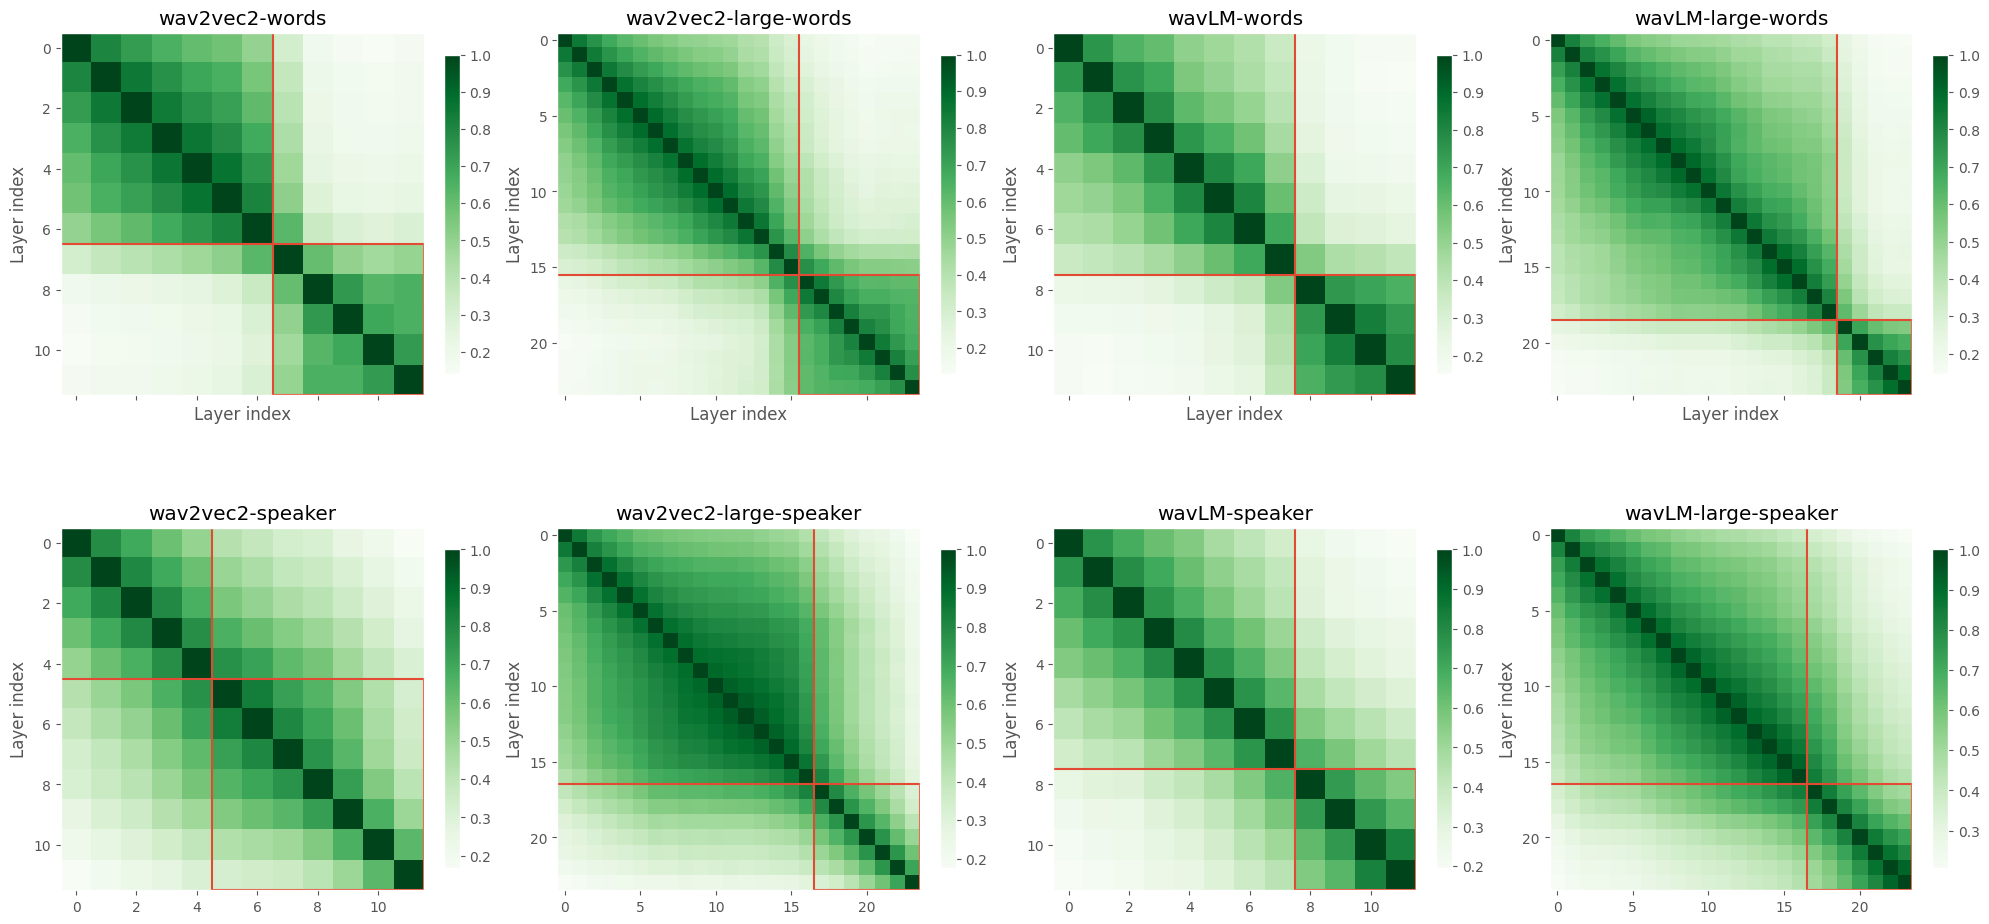

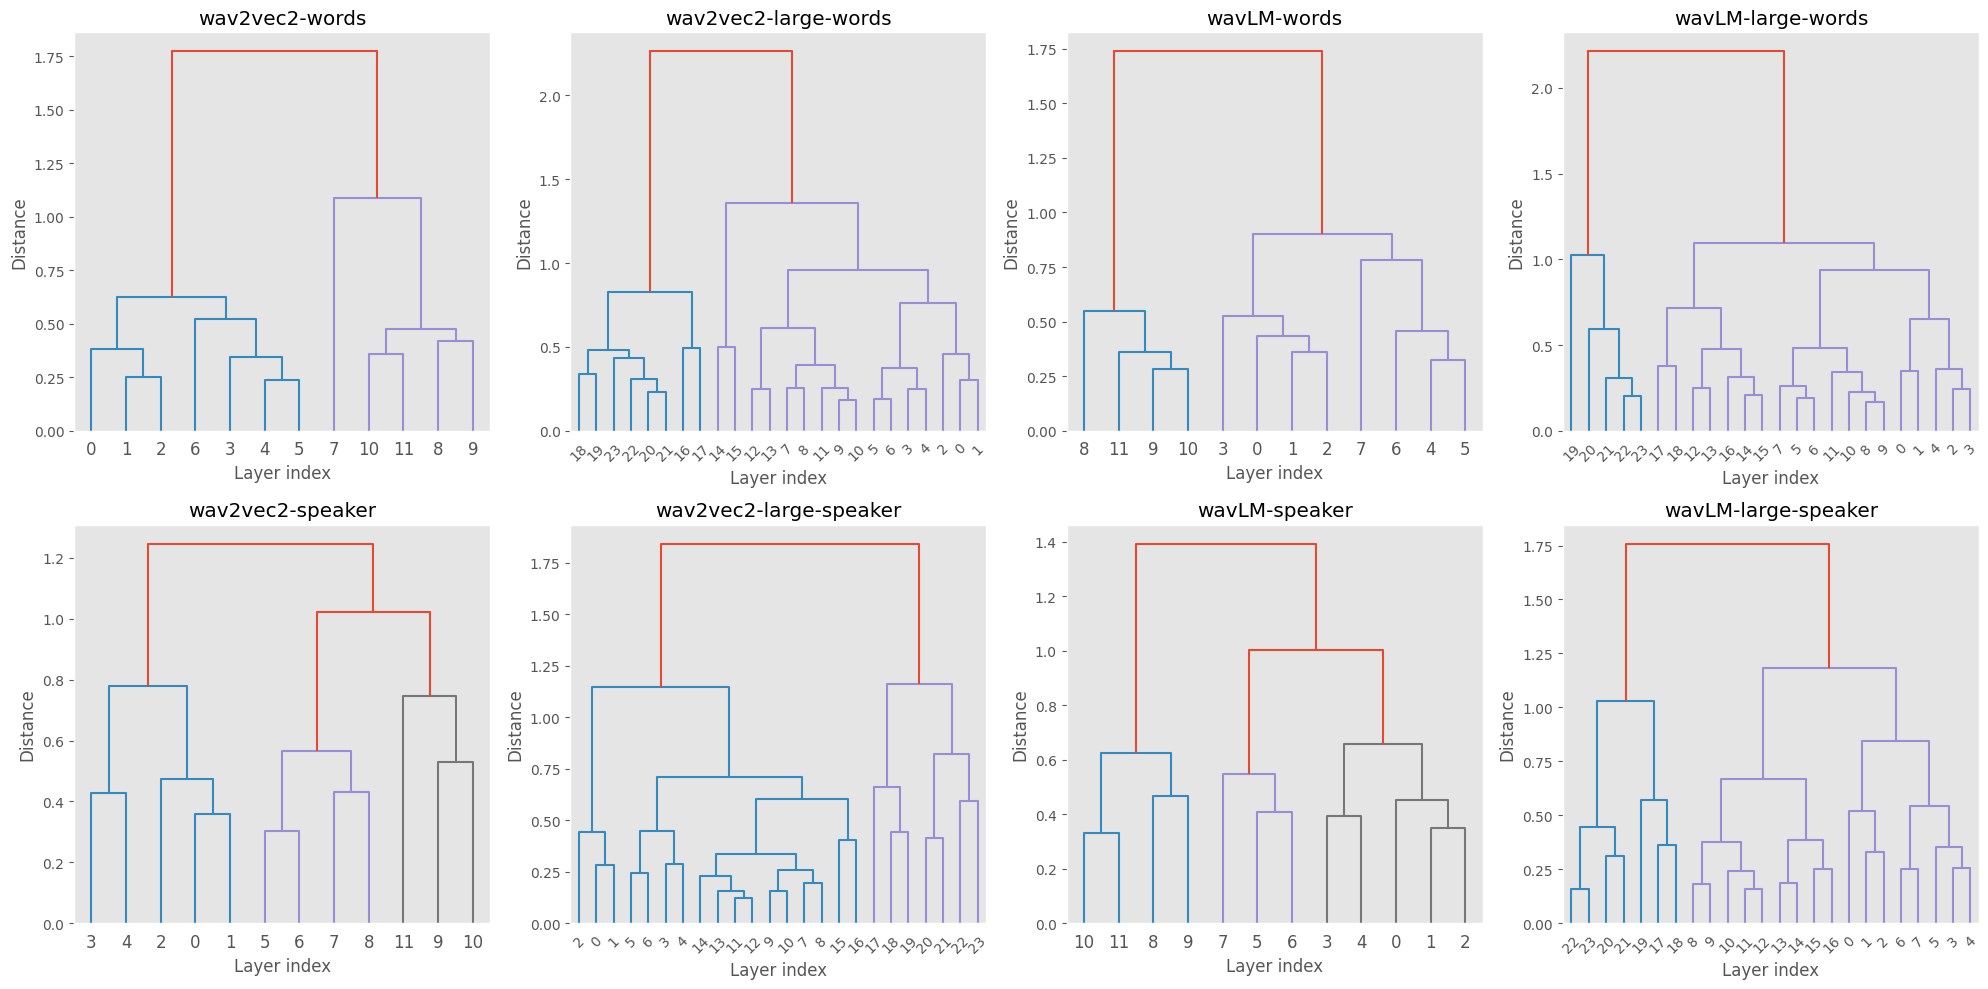

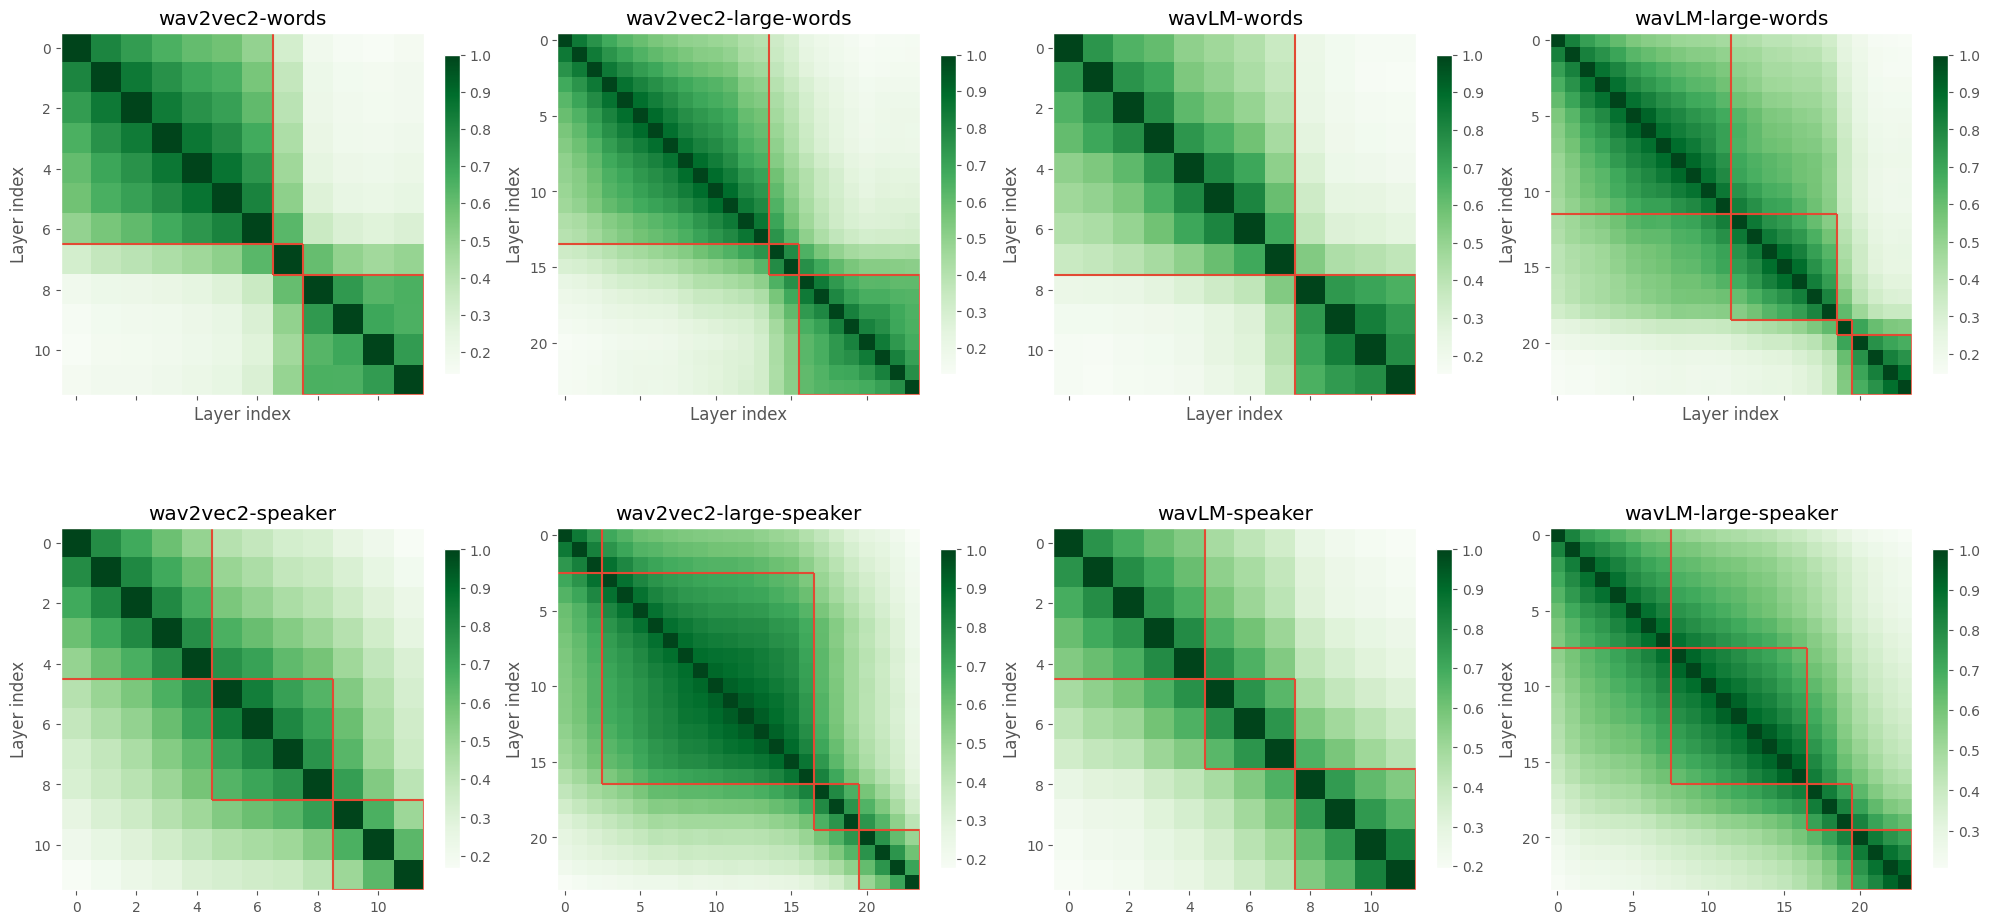

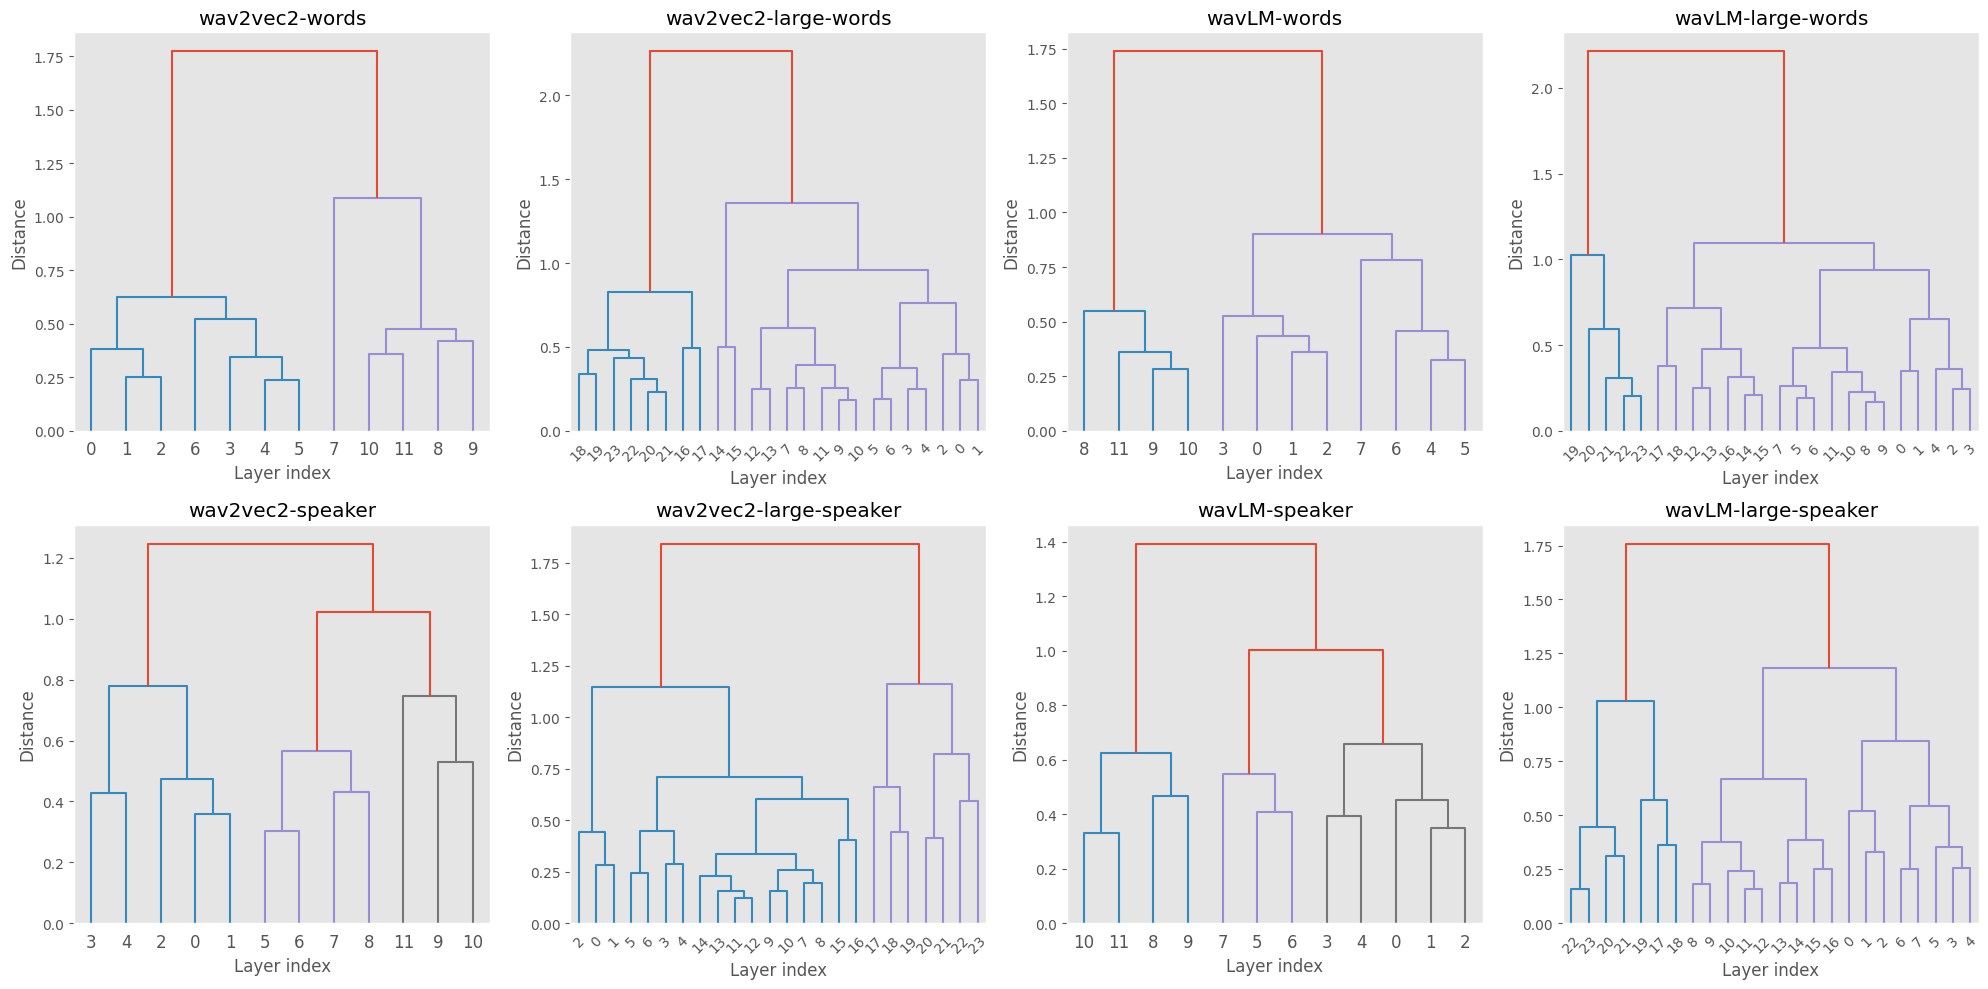

In [17]:
K = 8
EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/similarities")

### NUM CLUSTERS ###
num_clusters = 2
cluster_type = 'num_clusters'
linkage_type = 'average'

plot_hierarhical_clusters(EXP_PATH, K, num_clusters, linkage_type, cluster_type)

### DISTANCE-BASED ###
distance_threshold = 1.
cluster_type = 'distance_threshold'
linkage_type = 'average'

plot_hierarhical_clusters(EXP_PATH, K, distance_threshold, linkage_type, cluster_type)


In [207]:
from collections import Counter

def plot_sim_pruning_results(models, finetuning_types, pruning_filename, pruning_threshold, cluster_type, K, linkage_type, cluster_param, SIM_EXP_PATH, PRUNING_EXP_PATH, add_communities=True, pruning_criterias=[None, 'block-influence', 'adaptive-block-influence', 'knn-block-influence', 'adaptive-knn-block-influence']):

    sim_experiments = {f"{_m}-{_ft}": SIM_EXP_PATH / f"audio/{_m}-{_ft}/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth" for _m in models for _ft in finetuning_types}
    pruning_experiments = {f"{_m}-{_ft}": PRUNING_EXP_PATH / f"audio/{_m}-{_ft}/{pruning_filename}.pth" for _m in models for _ft in finetuning_types}

    if cluster_type == 'num_clusters':
        ALL_COMMUNITIES = get_communities(mutual_K=K, num_clusters=cluster_param, linkage_type=linkage_type, EXP_PATH=SIM_EXP_PATH, save=False)
    else:
        ALL_COMMUNITIES = get_communities(mutual_K=K, distance_threshold=cluster_param, linkage_type=linkage_type, EXP_PATH=SIM_EXP_PATH, save=False)

    print(
        f"pruning threshold: {pruning_threshold}",
        f"num clusters: {cluster_param}" if cluster_type == 'num_clusters' else f"distance threshold: {cluster_param}",
        f"linkage type: {linkage_type}",
        f"Mutual K: {K}",
    )
    for pruning_criteria in pruning_criterias:
        print(f"### NEW CRITERIA --> {pruning_criteria} ###")

        # Plot similarities
        j = 0 # reset columns
        acc_drops = []
        fig, axs = plt.subplots(3, len(models) * len(finetuning_types), figsize=(3 * len(models) * len(finetuning_types), 6), sharex='col', sharey='col')
        for _ft in finetuning_types:
            for _m in models:
                exp_name = f"{_m}-{_ft}"

                # Load results
                sim_res = torch.load(sim_experiments[f"{_m}-{_ft}"])
                pruning_res = torch.load(pruning_experiments[f"{_m}-{_ft}"])
                
                # Extract cosine similarities
                cos_between = torch.stack([elem['between'] for elem in sim_res['all-cosine-similarities']])
                
                # Extract CKA similarities
                cka = torch.stack(sim_res['all-cka-similarities'])
                cka_between = cka[:, 1::2, 1::2]

                # Extract mutual kNN similarities
                ks = [K]
                N_b = len(sim_res['all-mutual_knn-similarities']['between'])
                mutual_knn_between = {k: torch.stack([sim_res['all-mutual_knn-similarities']['between'][i][k] for i in range(N_b)]) for k in ks}

                if pruning_criteria is not None:
                    pruning_performance = torch.tensor(list(pruning_res['accuracy'][pruning_criteria].values())).mean(dim=1)
                    pruning_performance_change_ratio = abs(pruning_performance[0] - pruning_performance[1:]) / pruning_performance[:-1]
                    n_layers_to_remove = (pruning_performance_change_ratio > pruning_threshold).nonzero()[0].item() # add 1 for adjusting for difference computation but remove 1 for aligning with 0 meaning no pruning

                    mask = torch.zeros_like(cos_between[0, :, :])
                    if pruning_criteria not in ['forward', 'backward']:
                        if 'adaptive' in pruning_criteria:
                            pruning_order = torch.tensor(pruning_res[f'all-{pruning_criteria}s'])# .mode(dim=0).values # adjust for 1-indexing

                            pruning_order_corrected = []
                            for _elem in range(pruning_order.shape[1]):
                                _candidates = Counter(pruning_order[:, _elem].numpy())
                                _candidates = sorted(_candidates, key=lambda x: _candidates[x])[::-1]
                                for _key in _candidates:
                                    if _key not in pruning_order_corrected:
                                        pruning_order_corrected.append(_key)
                                        break
                            pruning_order = torch.tensor(pruning_order_corrected)
                            
                        else:
                            pruning_order = torch.stack(pruning_res[f'all-{pruning_criteria}s']).mean(dim=1).argsort(1).mode(dim=0).values + 1 # adjust for 1-indexing
                        
                        for _layer in pruning_order[:n_layers_to_remove]:
                            mask[_layer, :] = 1
                            mask[:, _layer] = 1
                    
                    elif pruning_criteria == 'forward':
                        print(n_layers_to_remove)
                        mask[1:n_layers_to_remove + 1, :] = 1
                        mask[:, 1:n_layers_to_remove + 1] = 1

                    else:
                        print(n_layers_to_remove)
                        mask[-n_layers_to_remove:, :] = 1
                        mask[:, -n_layers_to_remove:] = 1

                    acc_drops.append((pruning_performance[0] - pruning_performance[n_layers_to_remove-1])/pruning_performance[0]*100)

                # Plot cosine, CKA and kNN similarities
                plot_similarity_matrix(axs[0, j], cos_between.mean(dim=0), 'cosine', fig=fig)
                plot_similarity_matrix(axs[1, j], cka_between.mean(dim=0), 'cka', fig=fig)
                plot_similarity_matrix(axs[2, j], mutual_knn_between[K].mean(dim=0), 'knn', fig=fig)

                axs[2, j].set_xlabel('Layer index'); axs[2, j].set_xlabel('Layer index')

                for i in range(3): # rows
                    axs[i, j].set_yticks(np.arange(cos_between.shape[1])[::cos_between.shape[1] // 4])
                    axs[i, j].set_xticks(np.arange(cos_between.shape[1])[::cos_between.shape[1] // 4])
                    # Add pruning mask
                    if pruning_criteria is not None:
                        axs[i, j].imshow(abs(1-mask), cmap='Greys', alpha=0.4)                

                        if add_communities:
                            communities = ALL_COMMUNITIES[exp_name]
                            for c in range(len(communities)):
                                axs[i, j].hlines(y=min(communities[c]) - 0.5, xmin=min(communities[c]) - 0.5, xmax=max(communities[c]) + 0.5, color='C0')
                                axs[i, j].hlines(y=max(communities[c]) + 0.5, xmin=min(communities[c]) - 0.5, xmax=max(communities[c]) + 0.5, color='C0')
                                axs[i, j].vlines(x=min(communities[c]) - 0.5, ymin=min(communities[c]) - 0.5, ymax=max(communities[c]) + 0.5, color='C0')
                                axs[i, j].vlines(x=max(communities[c]) + 0.5, ymin=min(communities[c]) - 0.5, ymax=max(communities[c]) + 0.5, color='C0')

                if pruning_criteria is not None:
                    axs[0, j].set_title(f"{exp_name}\n$N_d={n_layers_to_remove} \\rightarrow {100-acc_drops[j]:.2f}$% cap.", fontsize=10)
                else:
                    axs[0, j].set_title(f"{exp_name}", fontsize=10)

                # Update column
                j += 1
        
        axs[0, 0].set_ylabel("Cosine")
        axs[1, 0].set_ylabel('CKA')
        axs[2, 0].set_ylabel('$k$NN ($k=8$)')

        bs = max(sim_res['all-mutual_knn-similarities']['within'][0].keys())
        fig.suptitle(f"Feature similarities ($B={bs}$)" + f" - {pruning_criteria} pruning" if pruning_criteria is not None else "", fontsize=18)
        fig.tight_layout()
        plt.show()

pruning threshold: 0.1 num clusters: 2 linkage type: average Mutual K: 8
### NEW CRITERIA --> None ###


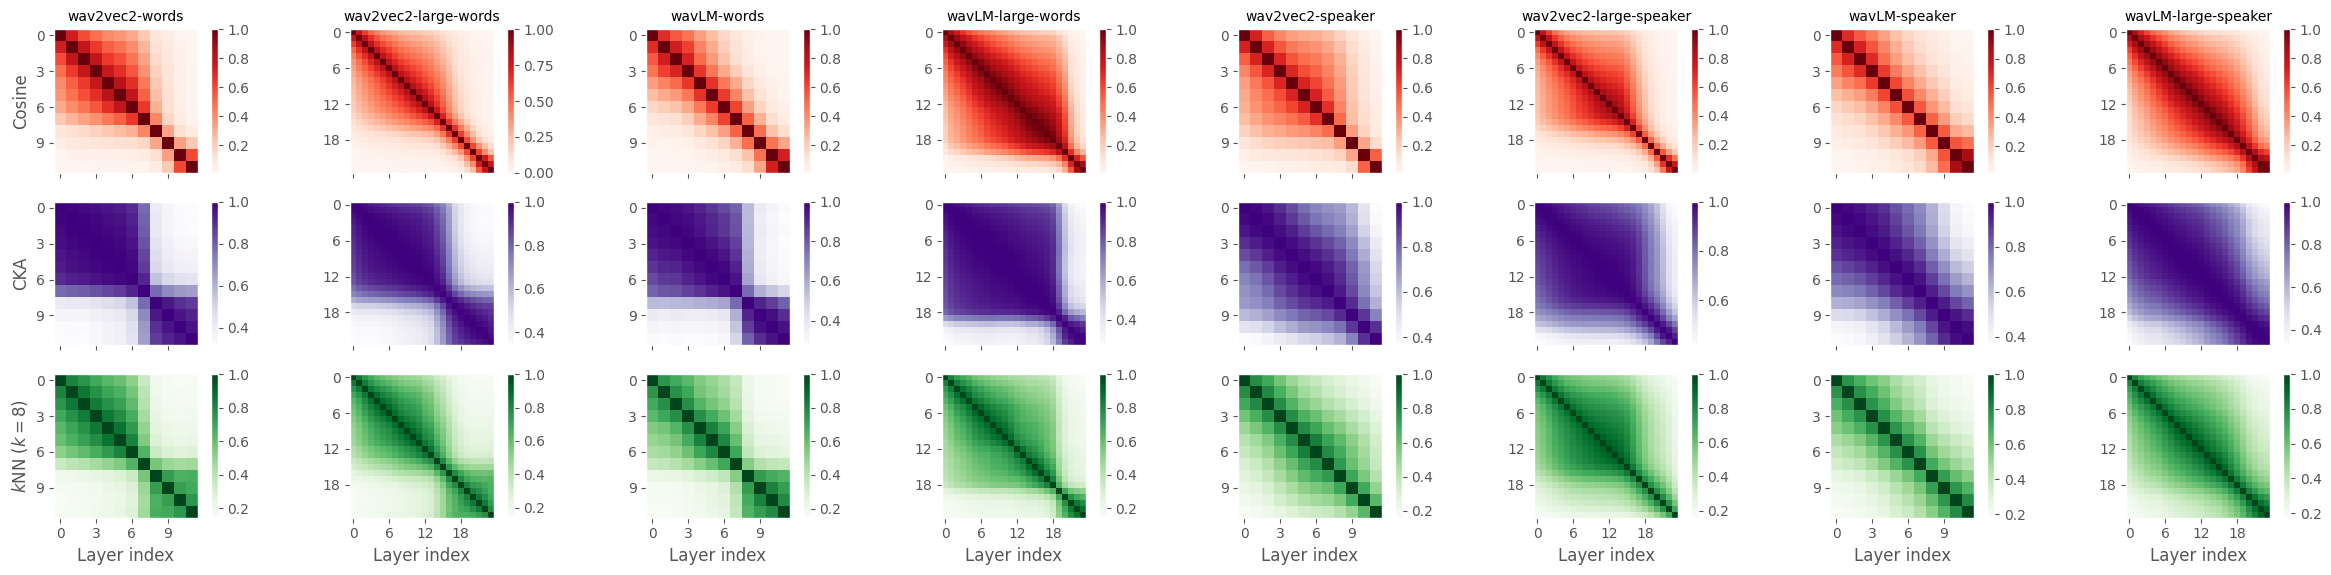

### NEW CRITERIA --> block-influence ###


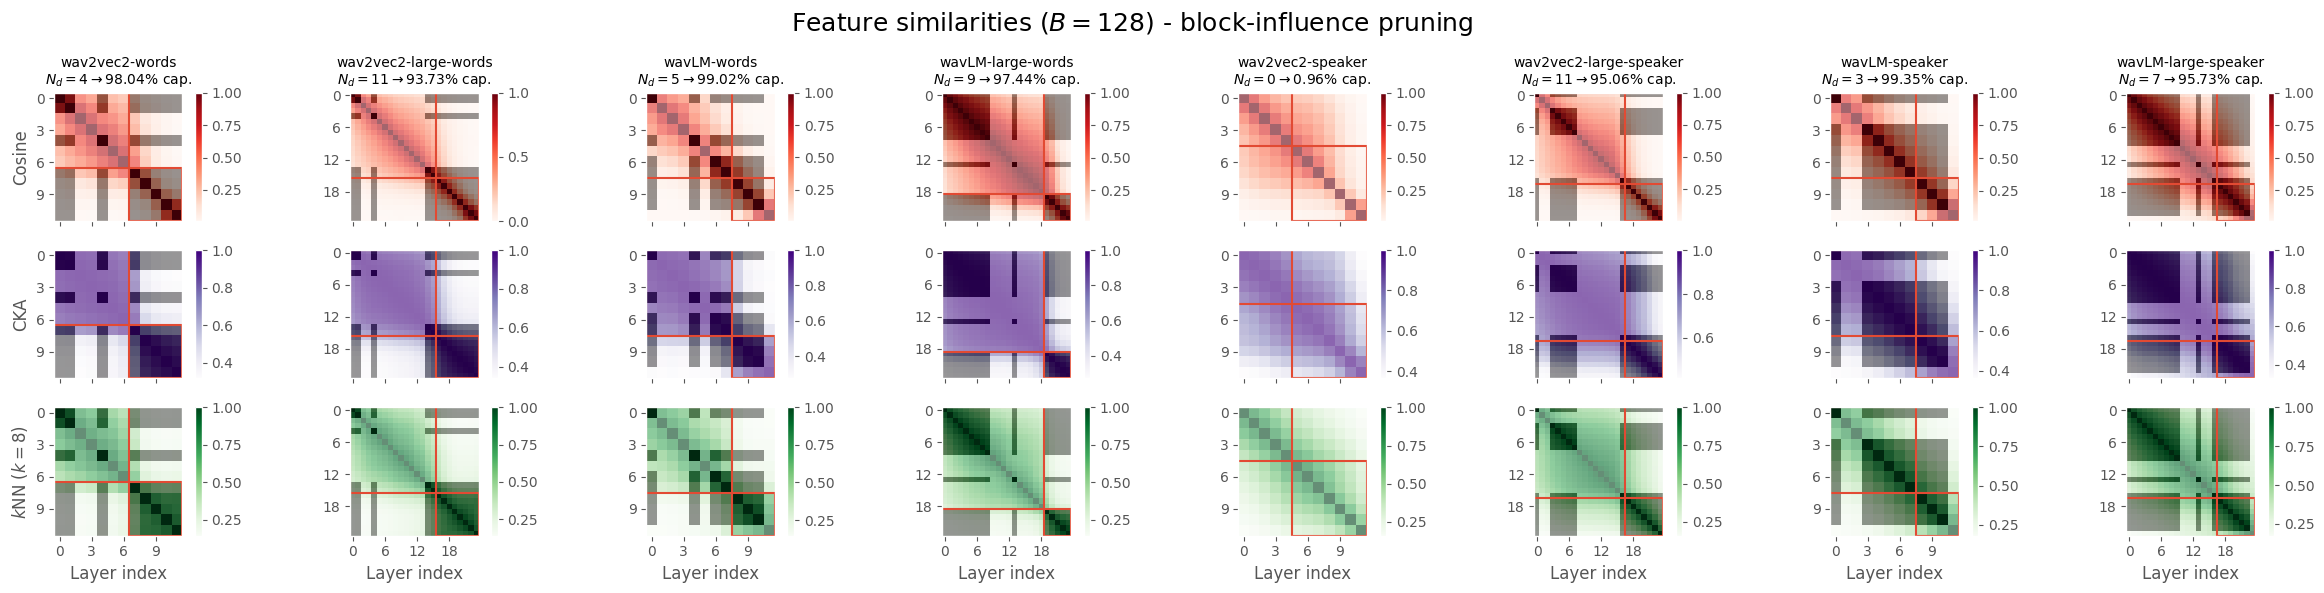

### NEW CRITERIA --> adaptive-block-influence ###


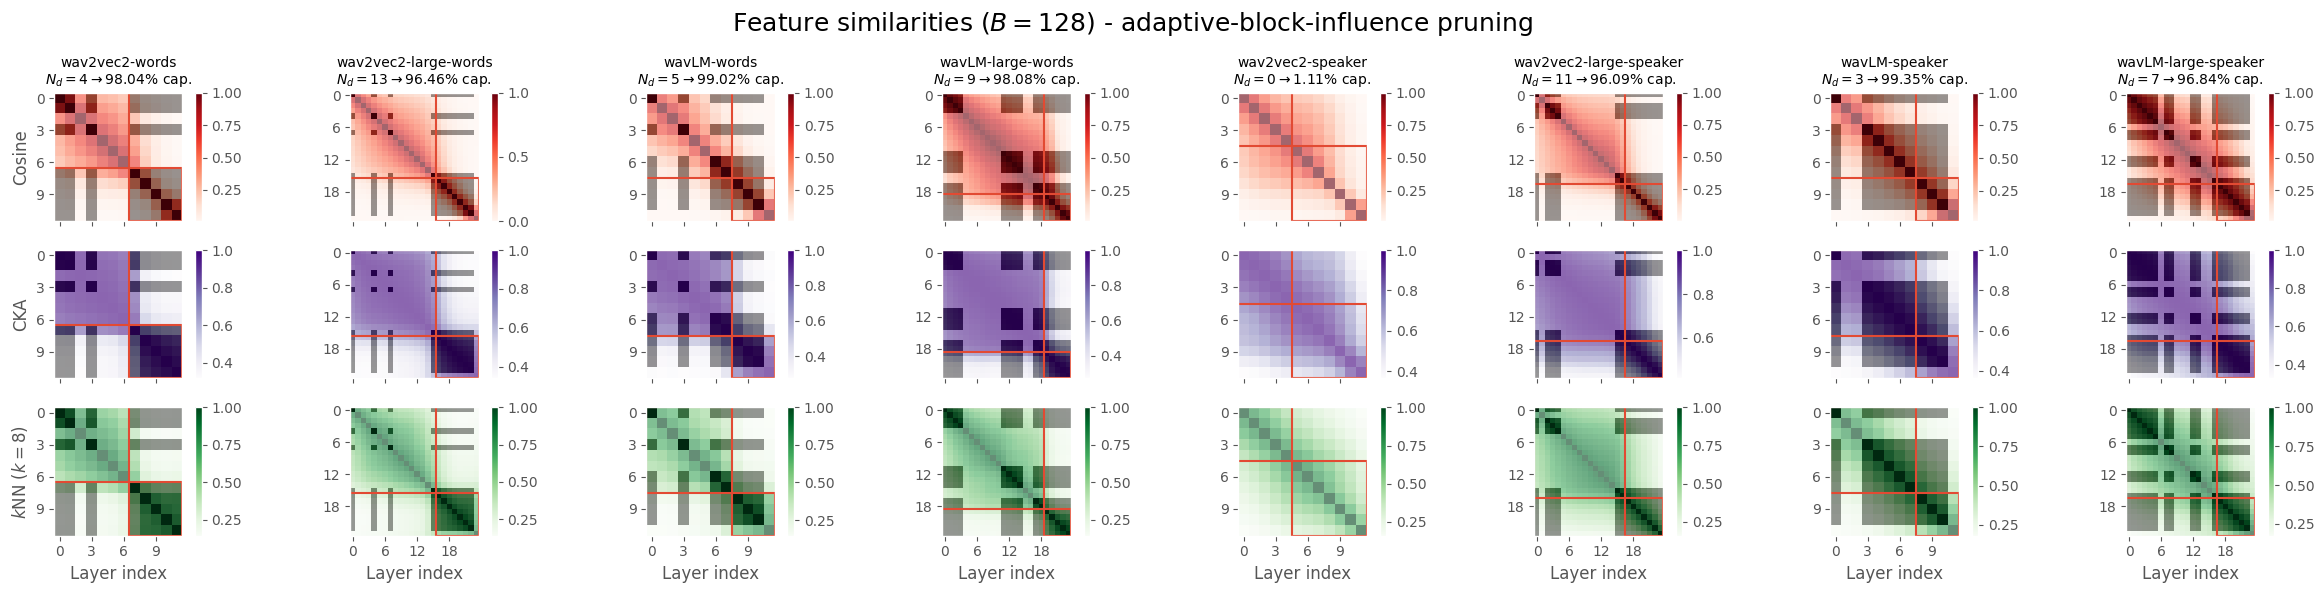

### NEW CRITERIA --> knn-block-influence ###


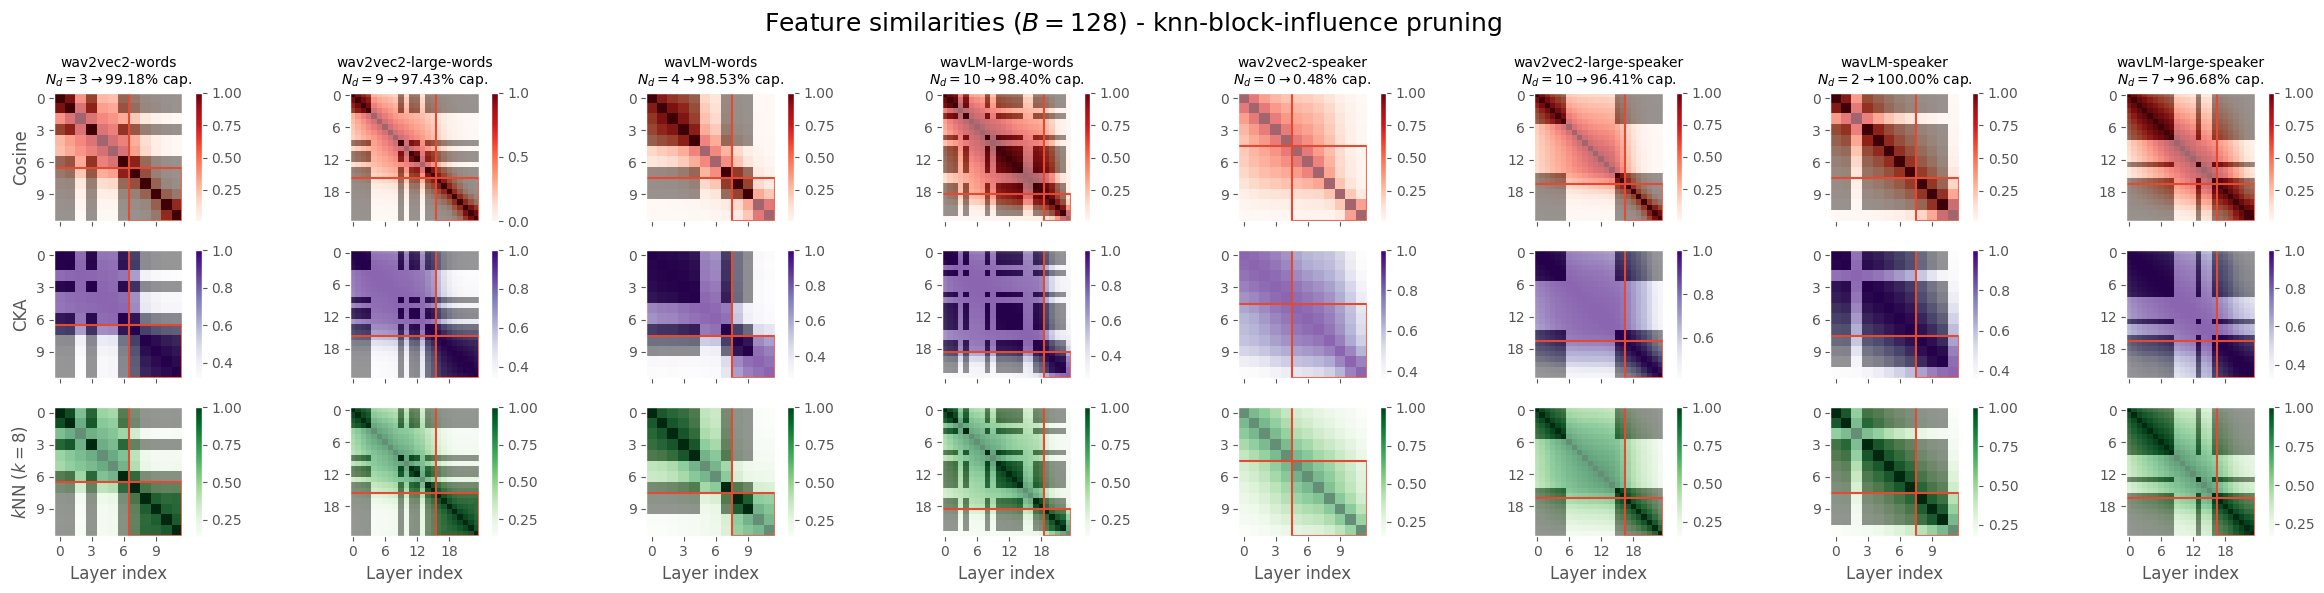

### NEW CRITERIA --> adaptive-knn-block-influence ###


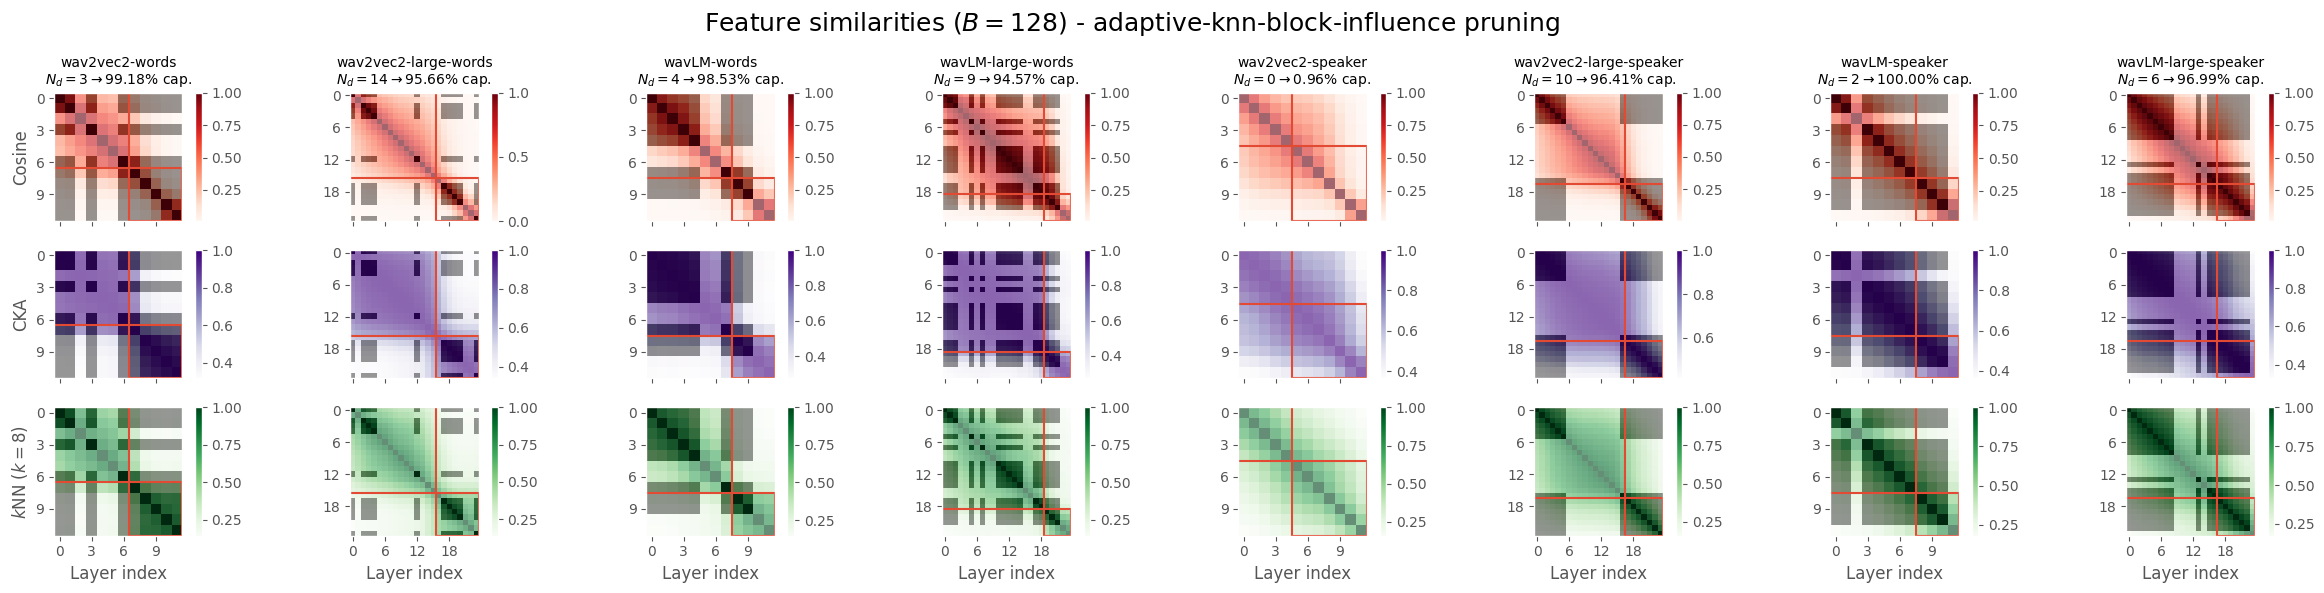

In [208]:
SIM_EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/similarities")
PRUNING_EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/pruning/adaptive")

models = ['wav2vec2', 'wav2vec2-large', 'wavLM', 'wavLM-large']
finetuning_types = ['words', 'speaker']
pruning_filename = "bs128_10iter_results"
pruning_threshold = 0.1
add_communities = True

K = 8
linkage_type = 'average'
num_clusters = 2
cluster_type = 'num_clusters'

plot_sim_pruning_results(models, finetuning_types, pruning_filename, pruning_threshold, cluster_type, K, linkage_type, num_clusters, SIM_EXP_PATH, PRUNING_EXP_PATH, add_communities)

pruning threshold: 0.1 distance threshold: 1.0 linkage type: average Mutual K: 8
### NEW CRITERIA --> None ###


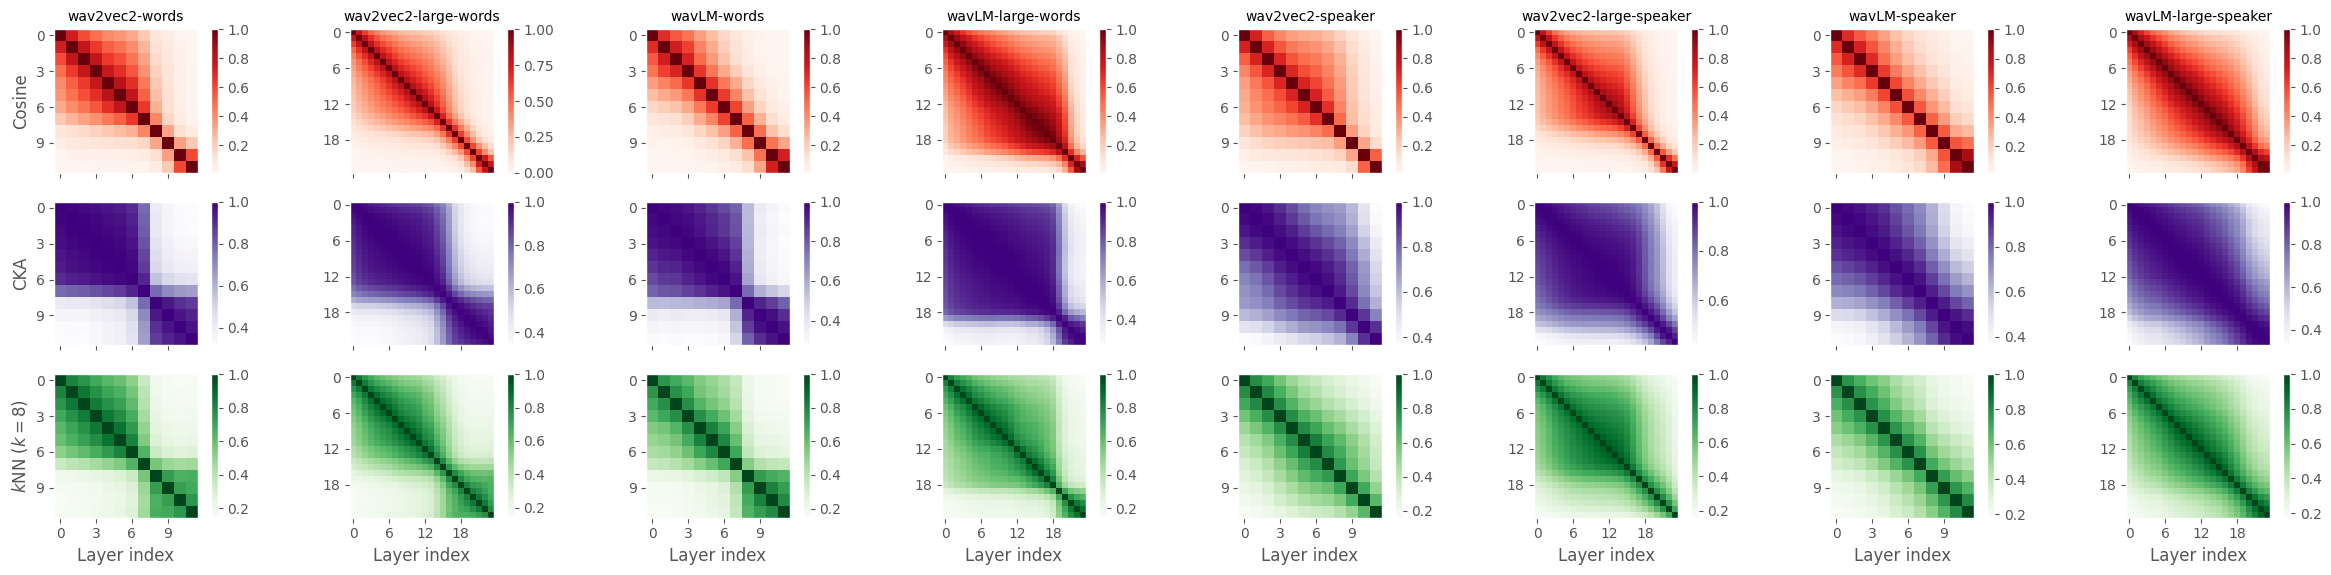

### NEW CRITERIA --> block-influence ###


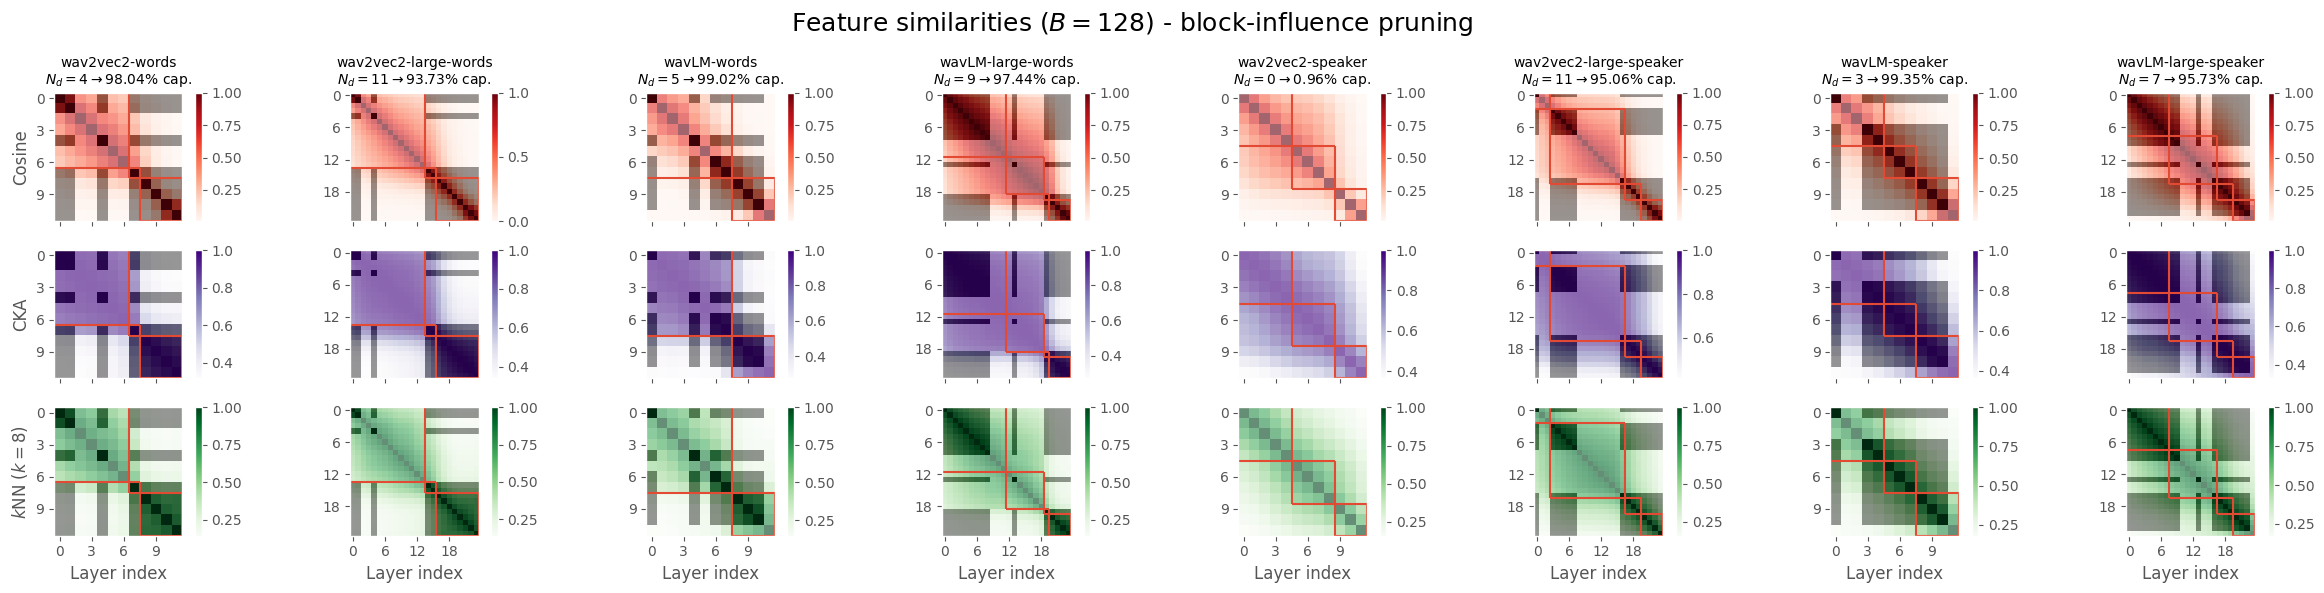

### NEW CRITERIA --> adaptive-block-influence ###


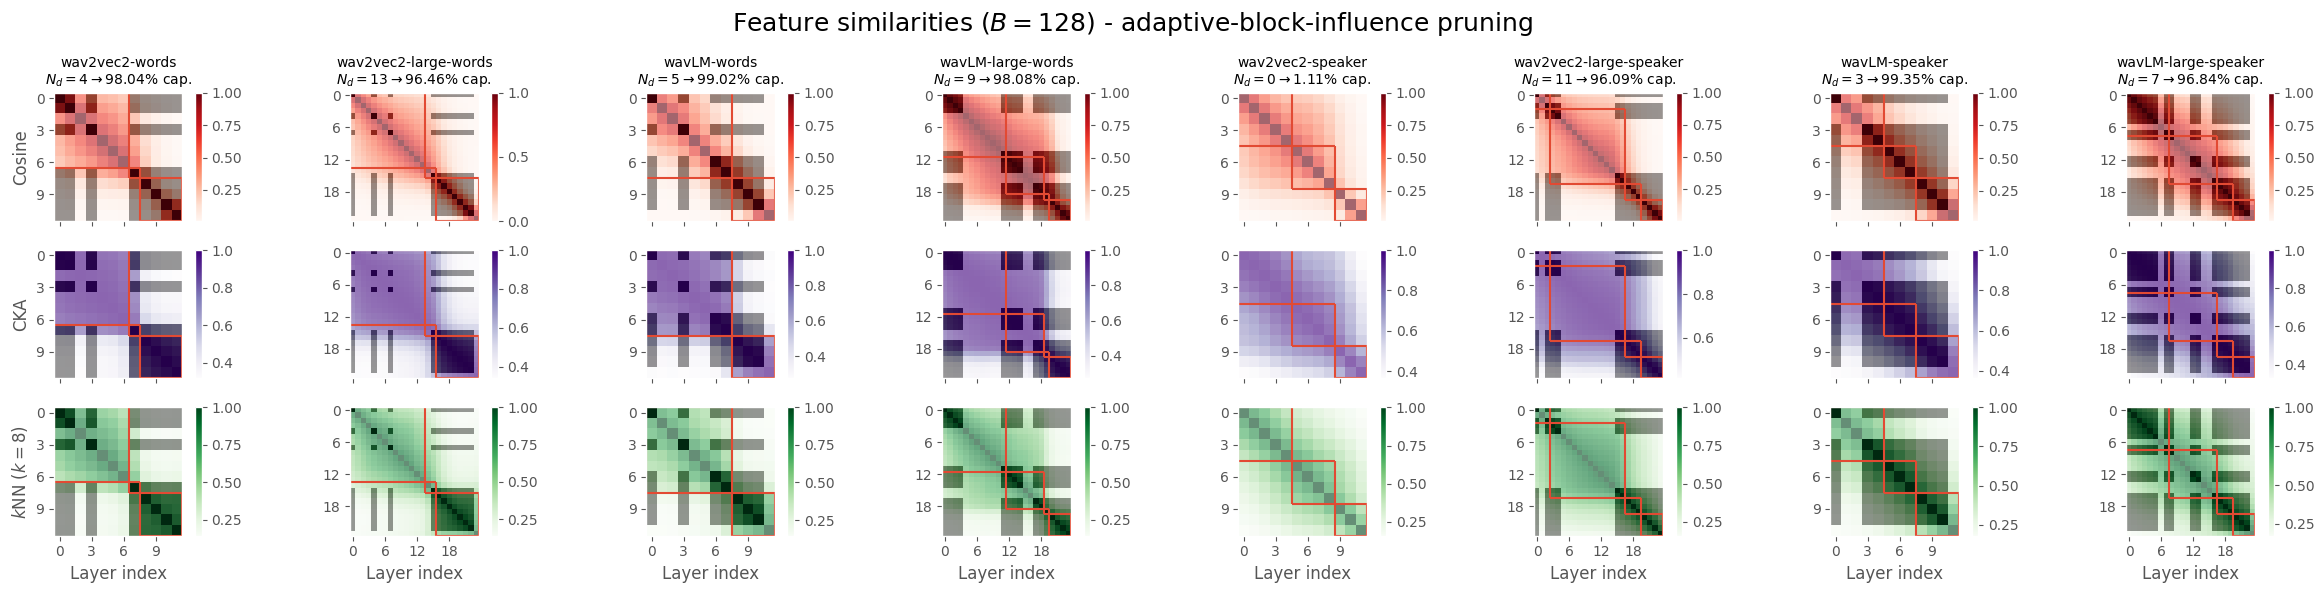

### NEW CRITERIA --> knn-block-influence ###


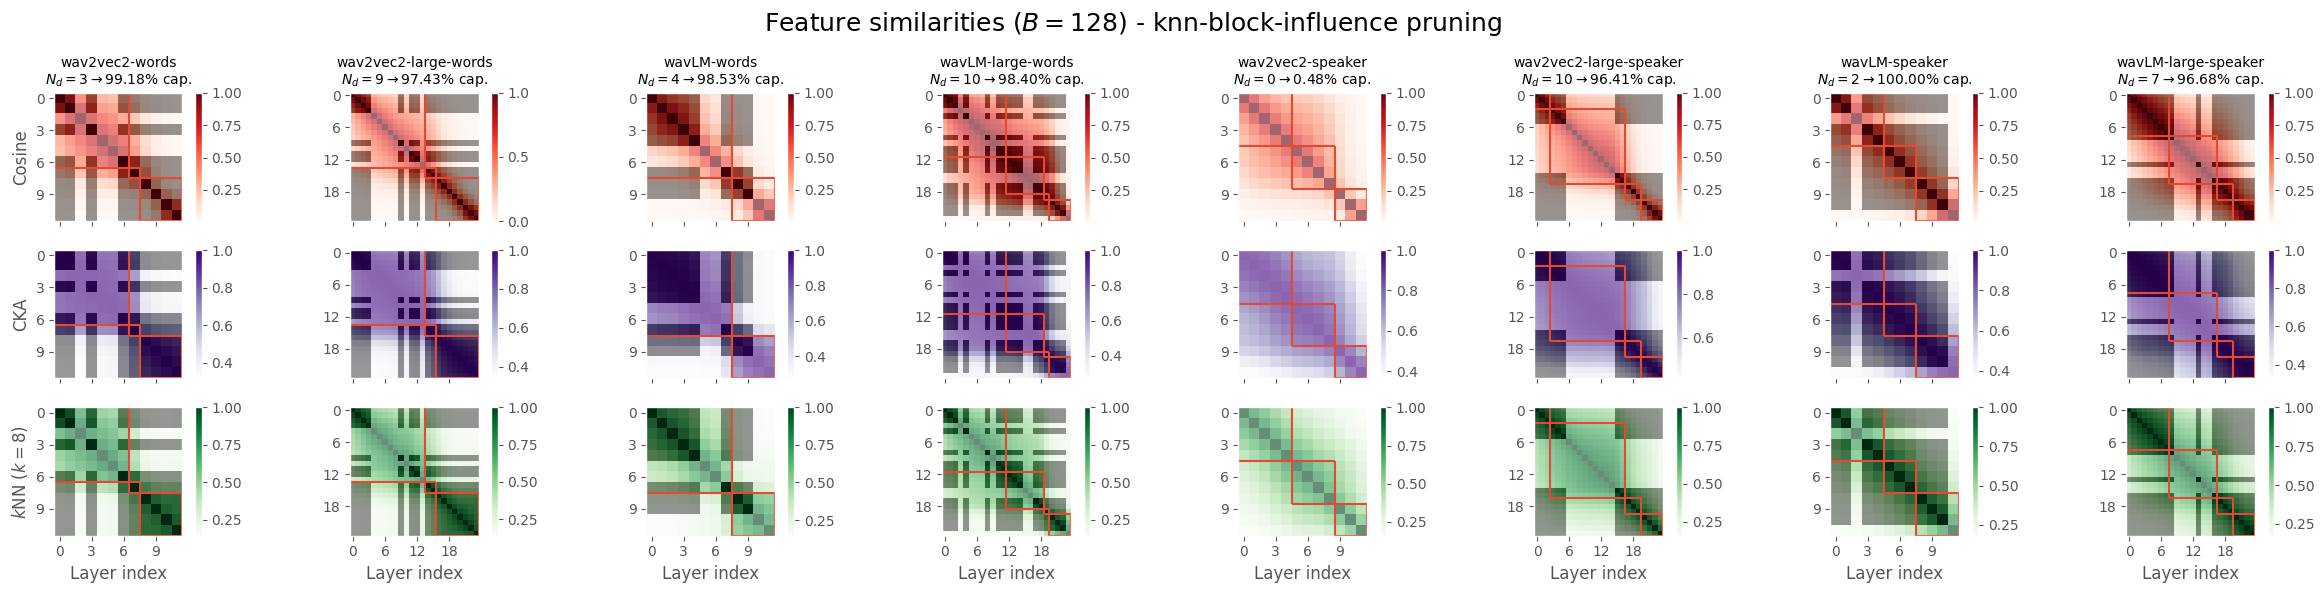

### NEW CRITERIA --> adaptive-knn-block-influence ###


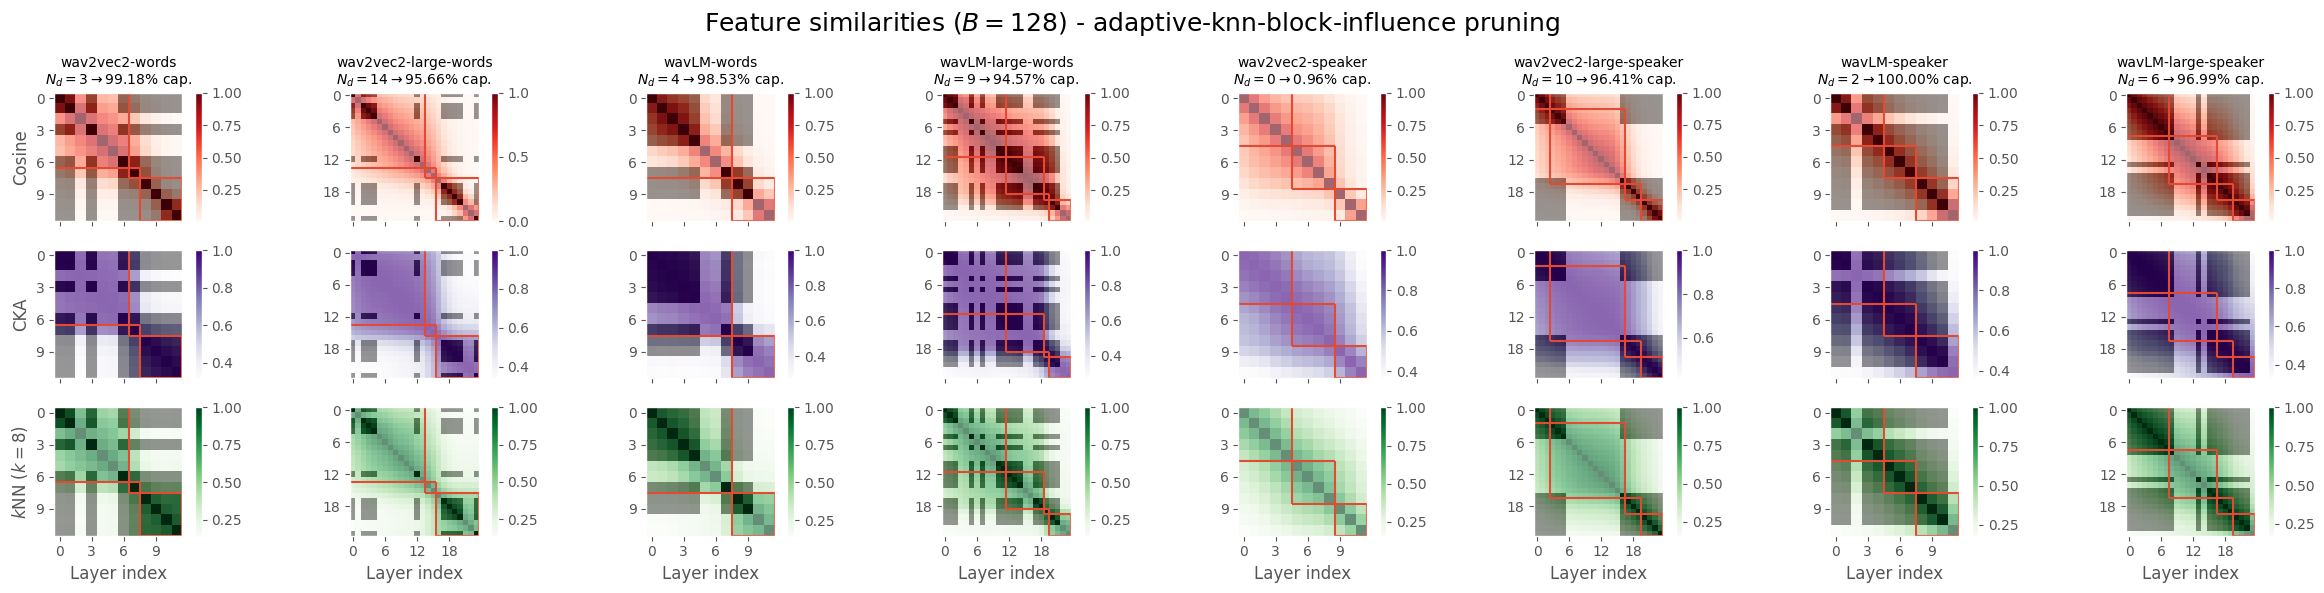

In [209]:
SIM_EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/similarities")
PRUNING_EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/pruning/adaptive")

models = ['wav2vec2', 'wav2vec2-large', 'wavLM', 'wavLM-large']
finetuning_types = ['words', 'speaker']
pruning_filename = "bs128_10iter_results"
pruning_threshold = 0.1
add_communities = True

K = 8
linkage_type = 'average'
distance_threshold = 1.
cluster_type = 'distance_threshold'

plot_sim_pruning_results(models, finetuning_types, pruning_filename, pruning_threshold, cluster_type, K, linkage_type, distance_threshold, SIM_EXP_PATH, PRUNING_EXP_PATH, add_communities)

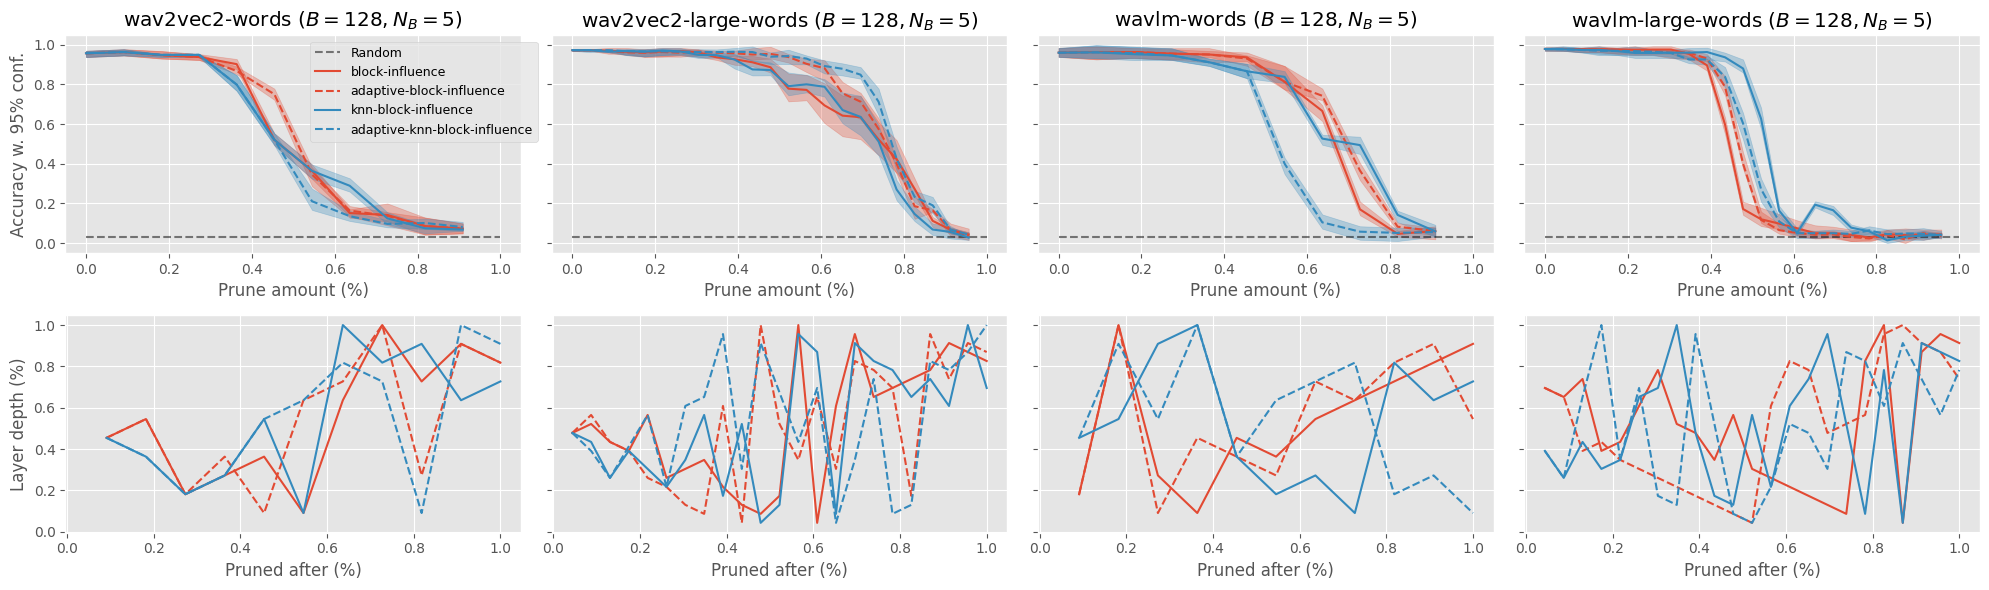

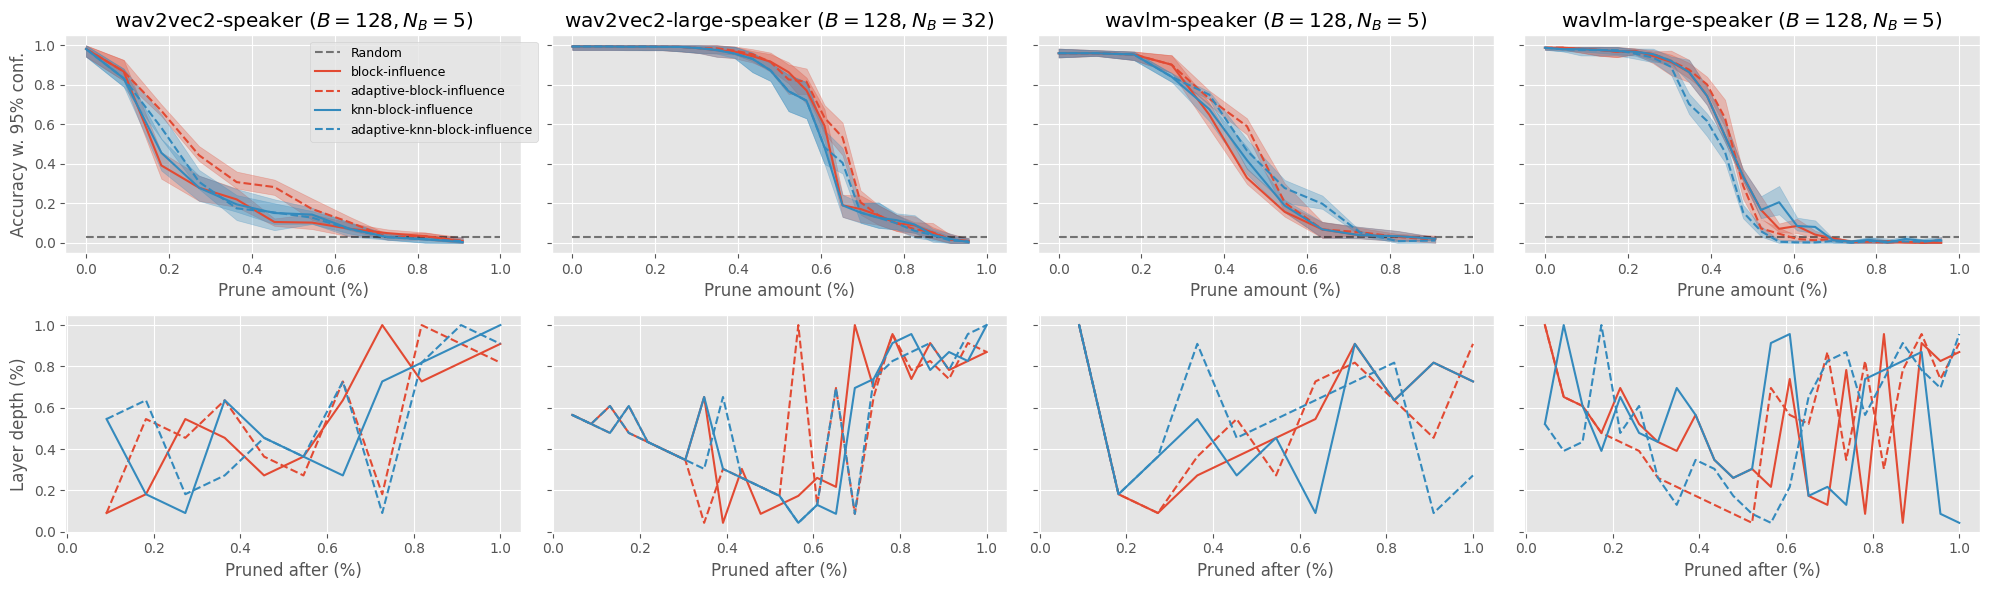

In [122]:
from collections import Counter

num_classes = 35
_conf = 95
_alpha = round((1 - _conf / 100), 2)

EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/pruning/adaptive")

for _ft_type in ['words', 'speaker']:

    all_results = {
        f'wav2vec2-{_ft_type}': torch.load(EXP_PATH / f"audio/wav2vec2-{_ft_type}/bs128_10iter_results.pth"),
        f'wav2vec2-large-{_ft_type}': torch.load(EXP_PATH / f"audio/wav2vec2-large-{_ft_type}/bs128_10iter_results.pth"),
        f'wavlm-{_ft_type}': torch.load(EXP_PATH / f"audio/wavlm-{_ft_type}/bs128_10iter_results.pth"),
        f'wavlm-large-{_ft_type}': torch.load(EXP_PATH / f"audio/wavlm-large-{_ft_type}/bs128_10iter_results.pth"),
    }

    fig, axs = plt.subplots(2, len(all_results.keys()), figsize=(5*len(all_results.keys()), 6), sharex='row', sharey='row')
    for i, (exp_name, results) in enumerate(all_results.items()):
        _row = 0
        n_batches = results['accuracy']['block-influence'][0].__len__()
        batch_size = results['all-block-influences'][0].shape[0]
        num_layers = results['all-block-influences'][0].shape[1] + 1

        # num_layers = 24 if 'large' in exp_name else 12
        axs[_row, i].hlines(1/num_classes, xmin=0, xmax=1, color='black', linestyle='--', alpha=0.5, label='Random')

        for p, pruning_strategy in enumerate(['block-influence', 'adaptive-block-influence', 'knn-block-influence', 'adaptive-knn-block-influence']):
            mean_accs = {k: torch.tensor(v).mean().item() for k, v in results['accuracy'][pruning_strategy].items()}
            lower_accs = {k: torch.tensor(v).quantile(_alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
            upper_accs = {k: torch.tensor(v).quantile(1 - _alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}

            xaxis = np.arange(len(mean_accs.keys())) / (num_layers - 1) # 
            axs[_row, i].fill_between(xaxis, list(lower_accs.values()), list(upper_accs.values()), alpha=0.3, color=f'C{p // 2}')
            axs[_row, i].plot(xaxis, list(mean_accs.values()), label=pruning_strategy, color=f'C{p // 2}', linestyle=['-', '--'][p % 2])

        axs[_row, i].set(xlabel='Prune amount (%)', title=f'{exp_name} ($B = {batch_size}, N_B = {n_batches}$)')

        bi_order = torch.argsort(torch.mean(torch.vstack(results['all-block-influences']), dim=0), descending=False) + 1 
        abi_order = torch.tensor(results['all-adaptive-block-influences'])# .mode(dim=0).values
        knn_order = torch.argsort(torch.mean(torch.vstack(results['all-knn-block-influences']), dim=0), descending=False) + 1
        aknn_order = torch.tensor(results['all-adaptive-knn-block-influences'])# .mode(dim=0).values

        aknn_corrected_order = []
        abi_corrected_order = []
        for _elem in range(num_layers-1):
            aknn_candidates = Counter(aknn_order[:, _elem].numpy())
            aknn_candidates = sorted(aknn_candidates, key=lambda x: aknn_candidates[x])[::-1]
            for _key in aknn_candidates:
                if _key not in aknn_corrected_order:
                    aknn_corrected_order.append(_key)
                    break

            abi_candidates = Counter(abi_order[:, _elem].numpy())
            abi_candidates = sorted(abi_candidates, key=lambda x: abi_candidates[x])[::-1]
            for _key in abi_candidates:
                if _key not in abi_corrected_order:
                    abi_corrected_order.append(_key)
                    break
        
        aknn_corrected_order, abi_corrected_order = torch.tensor(aknn_corrected_order), torch.tensor(abi_corrected_order)

        _row = 1
        names = ['BI', 'aBI', 'kNN', 'aKNN']
        for p, order in enumerate([bi_order, abi_corrected_order, knn_order, aknn_corrected_order]):

            xaxis = np.arange(num_layers)
            axs[_row, i].plot(order.sort().values / (num_layers - 1), order / (num_layers - 1), label=names[i], linestyle=['-', '--'][p % 2], color=f'C{p // 2}')
            axs[_row, i].set_xlabel('Pruned after (%)')

    axs[0, 0].set(ylabel=f'Accuracy w. {_conf}% conf.')
    axs[0, 0].legend(loc='upper right', fontsize=9, bbox_to_anchor=(1.05, 1))
    axs[1, 0].set_ylabel('Layer depth (%)')

    plt.tight_layout()
    plt.show()

```
wav2vec2-large (first - outside-in): 15 16 1 2 3 4 5 6 7 8 9 10 11 12 13 14 23 22 21 20 19 18 17
wav2vec2-large (first - inside-out): 15 16 14 13 12 11 10 9 8 7 6 5 4 3 2 1 17 18 19 20 21 22 23
wav2vec2-large (last - outside-in): 1 2 3 4 5 6 7 8 9 10 11 12 13 14 23 22 21 20 19 18 17 15 16
wav2vec2-large (last - inside-out): 14 13 12 11 10 9 8 7 6 5 4 3 2 1 17 18 19 20 21 22 23 15 16

wavLM-large (first - outside-in): 18 19 17 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 23 22 21 20
wavLM-large (first - inside-out): 18 19 17 16 15 14 13 12 11 10 9 8 7 6 5 4 3 2 1 20 21 22 23
wavLM-large (last - outside-in): 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 23 22 21 20 18 19 17
wavLM-large (last - inside-out): 16 15 14 13 12 11 10 9 8 7 6 5 4 3 2 1 20 21 22 23 18 19 17
```

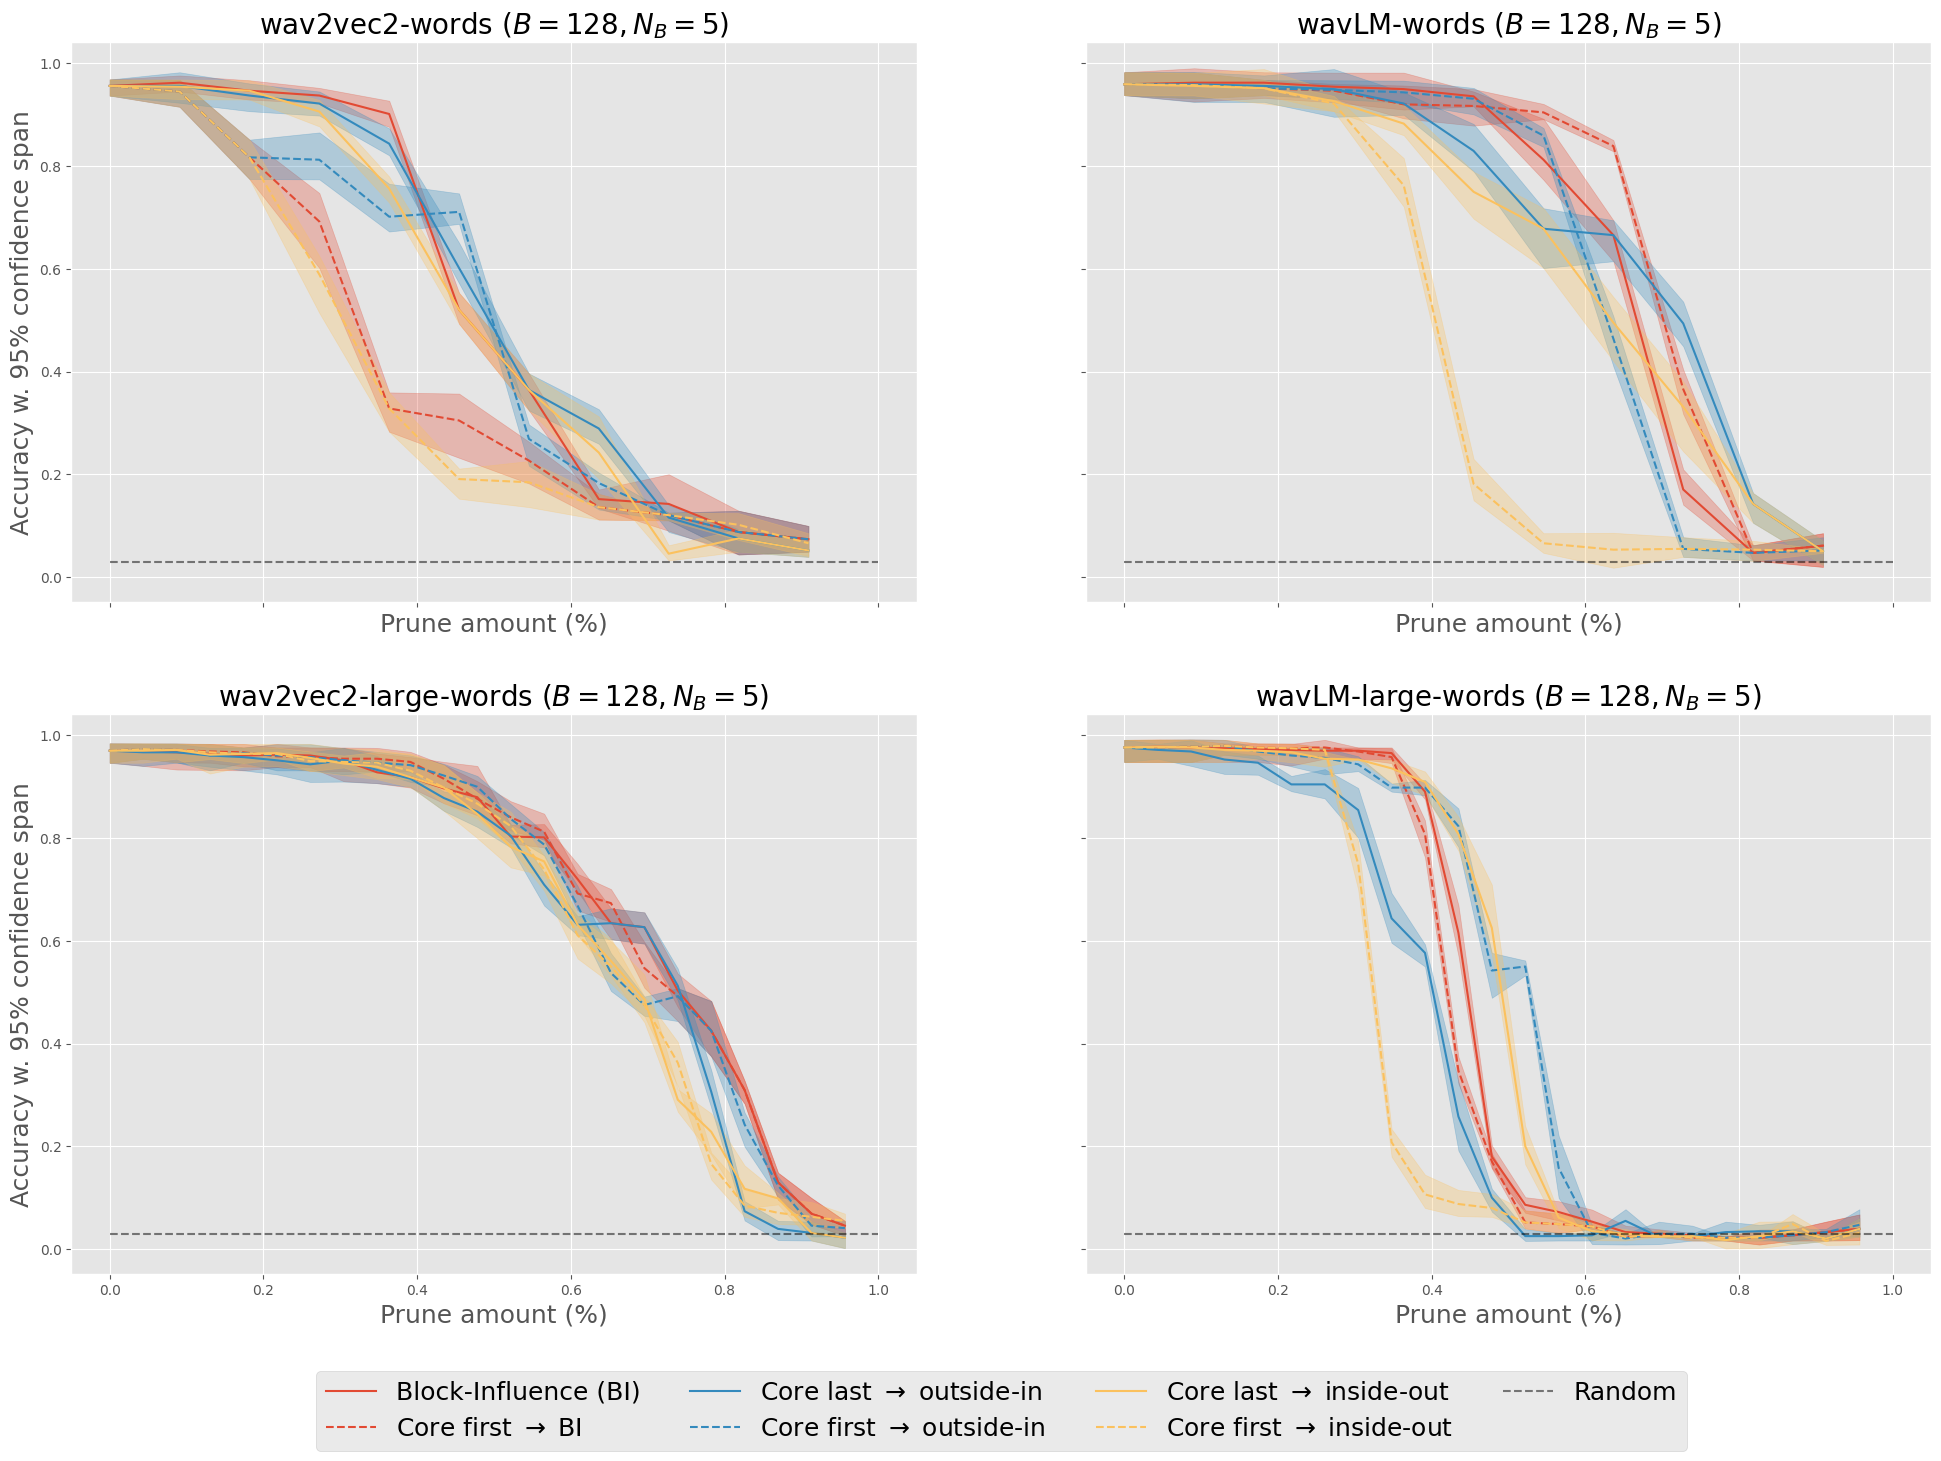

In [18]:
EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/pruning")

num_classes = 35
_conf = 95
_alpha = round((1 - _conf / 100), 2)

fig, axs = plt.subplots(2, 2, figsize=(8*(2 + 1), 16), sharey=True, sharex='col')

for _row, size in enumerate(['', '-large']):
    for a, a_name in enumerate(['outside-in-core-last', 'outside-in-core-first', 'inside-out-core-last', 'inside-out-core-first']):
        ls = '-' if 'core-last' in a_name else '--'
        color = 'C4' if 'inside-out' in a_name else 'C1'
        name = f'Core {a_name.split("-")[-1]} $\\rightarrow$ {"-".join(a_name.split("-")[:2])}'

        if a_name == 'outside-in-core-last': #and size == '':
            all_results = {
                f'wav2vec2{size}-words': torch.load(EXP_PATH / a_name / f"audio/wav2vec2{size}-words/within=False_['pruning-performance']_start-iter=0_pruned-by=['block-influence', 'knn-block-influence']_results.pth"),
                f'wavLM{size}-words': torch.load(EXP_PATH / a_name / f"audio/wavLM{size}-words/within=False_['pruning-performance']_start-iter=0_pruned-by=['block-influence', 'knn-block-influence']_results.pth"),
            }

        else:
            all_results = {
                f'wav2vec2{size}-words': torch.load(EXP_PATH / a_name / f"audio/wav2vec2{size}-words/within=False_['pruning-performance']_start-iter=0_pruned-by=[]_results.pth"),
                f'wavLM{size}-words': torch.load(EXP_PATH / a_name / f"audio/wavLM{size}-words/within=False_['pruning-performance']_start-iter=0_pruned-by=[]_results.pth"),
            }


        for i, (exp_name, results) in enumerate(all_results.items()):
            if a == 0:
                n_batches = results['accuracy']['block-influence'][0].__len__()
                batch_size = results['all-block-influences'][0].shape[0]
                num_layers = results['all-block-influences'][0].shape[1] + 1

                for strat_ in ['block-influence', 'core-first-block-influence']:
                    mean_accs = {k: torch.tensor(v).mean().item() for k, v in results['accuracy'][strat_].items()}
                    lower_accs = {k: torch.tensor(v).quantile(_alpha / 2).item() for k, v in results['accuracy'][strat_].items()}
                    upper_accs = {k: torch.tensor(v).quantile(1 - _alpha / 2).item() for k, v in results['accuracy'][strat_].items()}
    
                    xaxis = np.arange(len(mean_accs.keys())) / len(mean_accs.keys())
                    axs[_row, i].fill_between(xaxis, list(lower_accs.values()), list(upper_accs.values()), alpha=0.3, color='C0')
                    axs[_row, i].plot(xaxis, list(mean_accs.values()), label='Core first $\\rightarrow$ BI' if 'core' in strat_ else '$k$NN' if 'knn' in strat_ else 'Block-Influence (BI)', linestyle='--' if 'core' in strat_ else '-', color='C0' if 'knn' not in strat_ else 'C3')
                    
            pruning_strategy = 'custom'
            mean_accs = {k: torch.tensor(v).mean().item() for k, v in results['accuracy'][pruning_strategy].items()}
            lower_accs = {k: torch.tensor(v).quantile(_alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
            upper_accs = {k: torch.tensor(v).quantile(1 - _alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
            
            xaxis = np.arange(len(mean_accs.keys())) / len(mean_accs.keys())
            axs[_row, i].fill_between(xaxis, list(lower_accs.values()), list(upper_accs.values()), alpha=0.3, color=color)
            axs[_row, i].plot(xaxis, list(mean_accs.values()), label=name if pruning_strategy == 'custom' else pruning_strategy, linestyle=ls, color=color)
            axs[_row, i].set_xlabel('Prune amount (%)', fontsize=18)
            axs[_row, i].set_title(f'{exp_name} ($B = {batch_size}, N_B = {n_batches}$)', fontsize=20)

    axs[_row, 0].set_ylabel(f'Accuracy w. {_conf}% confidence span', fontsize=18)

for i in range(2):
    for j in range(2):
        axs[i, j].hlines(1/num_classes, xmin=0, xmax=1, color='black', linestyle='--', alpha=0.5, label='Random')

axs[0, 0].legend(fontsize=18, bbox_to_anchor=(1.1, -1.35), loc='upper center', ncols=4)
plt.show()

### Mimicking Network

In [127]:
from transformer_redundancy.models.audio import Wav2VecForLayerwiseAnalysis
from transformer_redundancy.train_surrogate import FeatureReproducingModel, TransformerBasedMimicker

In [154]:
analyzer = Wav2VecForLayerwiseAnalysis("wav2vec2-words", "../models", 'cuda')

num_params_dict, of_encoder, of_wav2vec2, of_full_model = {}, {}, {}, {}
for _prune_amount in range(analyzer.num_layers):
    _model, _ = analyzer.load_model()
    encoder_layers = _model.wav2vec2.encoder.layers
    for _layer_idx in range(_prune_amount):
        del encoder_layers[analyzer.num_layers - _layer_idx - 1]

    _model.wav2vec2.encoder.layers = encoder_layers
    num_params_dict[_prune_amount] = sum(p.numel() for p in _model.wav2vec2.encoder.parameters())
    of_encoder[_prune_amount] = num_params_dict[_prune_amount] / sum(p.numel() for p in analyzer.model.wav2vec2.encoder.parameters())
    of_wav2vec2[_prune_amount] = num_params_dict[_prune_amount] / sum(p.numel() for p in analyzer.model.wav2vec2.parameters())
    of_full_model[_prune_amount] = num_params_dict[_prune_amount] / sum(p.numel() for p in analyzer.model.parameters())

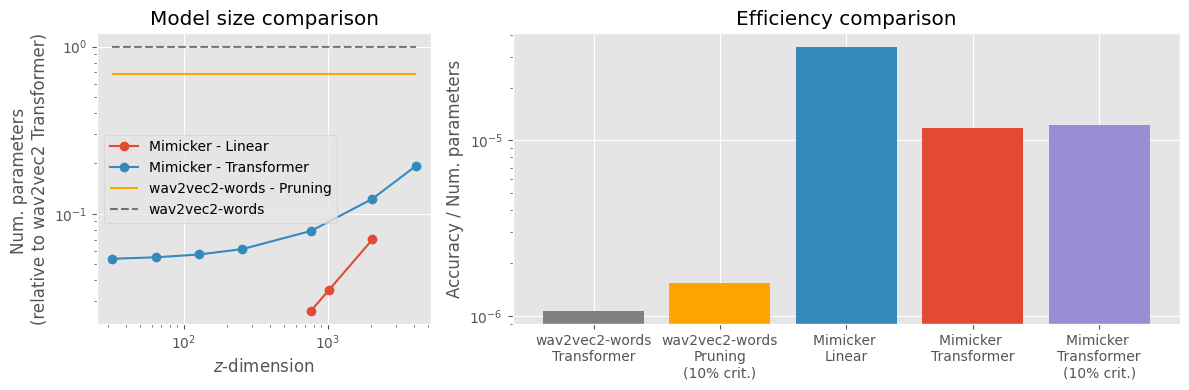

In [260]:
model_name = 'wav2vec2-words'
pruning_n_layers_best = 4

EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/surrogate_shared")

fig, axs = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 2]})
num_params = {'linear': {}, 'transformer': {}}
for model_type in ['linear', 'transformer']:
    for hidden_dim in [32, 64, 128, 256, 768, 1024, 2048, 4096]:
        try:
            state_dict = torch.load(EXP_PATH / f"speech_commands/{model_name}/mimicker_hidden_dim={hidden_dim}_lr=0.001_bs=128_layers=[7, 11]_{model_type}.pt")
            if model_type == 'linear':
                model = FeatureReproducingModel(in_dim=768, embedding_dim=768, hidden_dim=hidden_dim)
            else:
                model = TransformerBasedMimicker(embedding_dim=768, hidden_dim=hidden_dim)
            model.load_state_dict(state_dict)

            num_params[model_type][hidden_dim] = sum(p.numel() for p in model.parameters())

        except FileNotFoundError:
            continue

    axs[0].plot(num_params[model_type].keys(), np.array(list(num_params[model_type].values())) / num_params_dict[0], marker='o', label=f'Mimicker - {model_type.capitalize()}', color='C1' if model_type == 'transformer' else 'C0')

axs[0].hlines(of_encoder[pruning_n_layers_best], xmin=min(num_params['transformer'].keys()), xmax=max(num_params['transformer'].keys()), color='orange', linestyle='-', label=f'{model_name} - Pruning')
axs[0].hlines(1, xmin=min(num_params['transformer'].keys()), xmax=max(num_params['transformer'].keys()), color='black', linestyle='--', alpha=0.5, label=f'{model_name}')
axs[0].set_xscale('log'); axs[0].set_yscale('log')
axs[0].set_xlabel('$z$-dimension')
axs[0].set_ylabel('Num. parameters \n(relative to wav2vec2 Transformer)')
axs[0].legend(loc='center left')

# acc / num_params
efficiency_acc = { 
    f'{model_name}\nTransformer': 96 / num_params_dict[0],
    f'{model_name}\nPruning\n({pruning_threshold*100:.0f}% crit.)': 96 * 0.9804 / num_params_dict[pruning_n_layers_best],
    f'Mimicker \nLinear': 81 / num_params['linear'][768],
    f'Mimicker \nTransformer': 83 / num_params['transformer'][768],
    f'Mimicker \nTransformer\n({pruning_threshold*100:.0f}% crit.)': 96 * (1-pruning_threshold) / num_params['transformer'][768],

}
axs[1].bar(efficiency_acc.keys(), efficiency_acc.values(), color=['gray', 'orange', 'C1', 'C0', 'C2'])
axs[1].set_ylabel('Accuracy / Num. parameters')

axs[0].set_title('Model size comparison')
axs[1].set_title('Efficiency comparison')
axs[1].set_yscale('log')
plt.tight_layout()
plt.show()

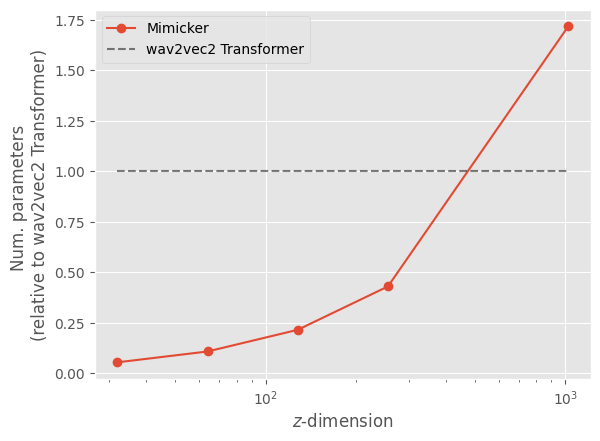

In [160]:
EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/surrogate")

num_params = {}
for hidden_dim in [32, 64, 128, 256, 1024]:
    try:
        state_dict = torch.load(EXP_PATH / f"speech_commands/wav2vec2-words/mimicer_hidden_dim={hidden_dim}_lr=0.0001_bs=128_layers=[7, 11].pt")
        model = FeatureReproducingModel(in_dim=49*768, embedding_dim=49*768, hidden_dim=hidden_dim)
        model.load_state_dict(state_dict)

        num_params[hidden_dim] = sum(p.numel() for p in model.parameters())

    except FileNotFoundError:
        continue

plt.plot(num_params.keys(), np.array(list(num_params.values())) / num_params_dict[0], marker='o', label='Mimicker')
plt.hlines(1, xmin=min(num_params.keys()), xmax=max(num_params.keys()), color='black', linestyle='--', alpha=0.5, label='wav2vec2 Transformer')
plt.xscale('log')
plt.xlabel('$z$-dimension')
plt.ylabel('Num. parameters \n(relative to wav2vec2 Transformer)')
plt.legend()
plt.show()

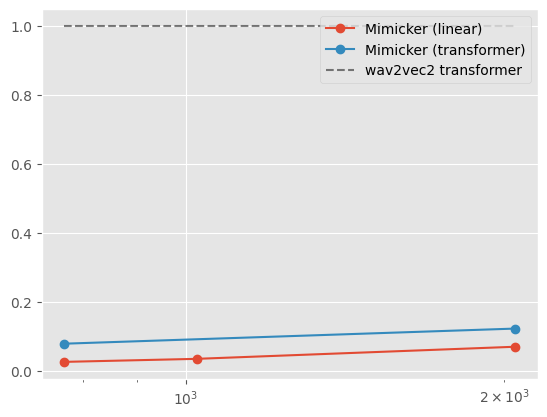

In [12]:
EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/surrogate_shared")

num_params = {}
num_params_transformer = {}
for hidden_dim in [128, 768, 1024, 2048]:
    try:
        state_dict = torch.load(EXP_PATH / f"speech_commands/wav2vec2-words/mimicker_hidden_dim={hidden_dim}_lr=0.001_bs=128_layers=[7, 11]_linear.pt")
        model = FeatureReproducingModel(in_dim=768, embedding_dim=768, hidden_dim=hidden_dim)
        model.load_state_dict(state_dict)
        num_params[hidden_dim] = sum(p.numel() for p in model.parameters())

        state_dict = torch.load(EXP_PATH / f"speech_commands/wav2vec2-words/mimicker_hidden_dim={hidden_dim}_lr=0.001_bs=128_layers=[7, 11]_transformer.pt")
        model = TransformerBasedMimicker(embedding_dim=768, hidden_dim=hidden_dim)
        model.load_state_dict(state_dict)
        num_params_transformer[hidden_dim] = sum(p.numel() for p in model.parameters())

    except FileNotFoundError:
        continue

plt.plot(num_params.keys(), np.array(list(num_params.values())) / n_params_wav2vec2_transformer, marker='o', label='Mimicker (linear)')
plt.plot(num_params_transformer.keys(), np.array(list(num_params_transformer.values())) / n_params_wav2vec2_transformer, marker='o', label='Mimicker (transformer)')
plt.hlines(1, xmin=min(num_params.keys()), xmax=max(num_params.keys()), color='black', linestyle='--', alpha=0.5, label='wav2vec2 transformer')
plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.show()

### Procrustes

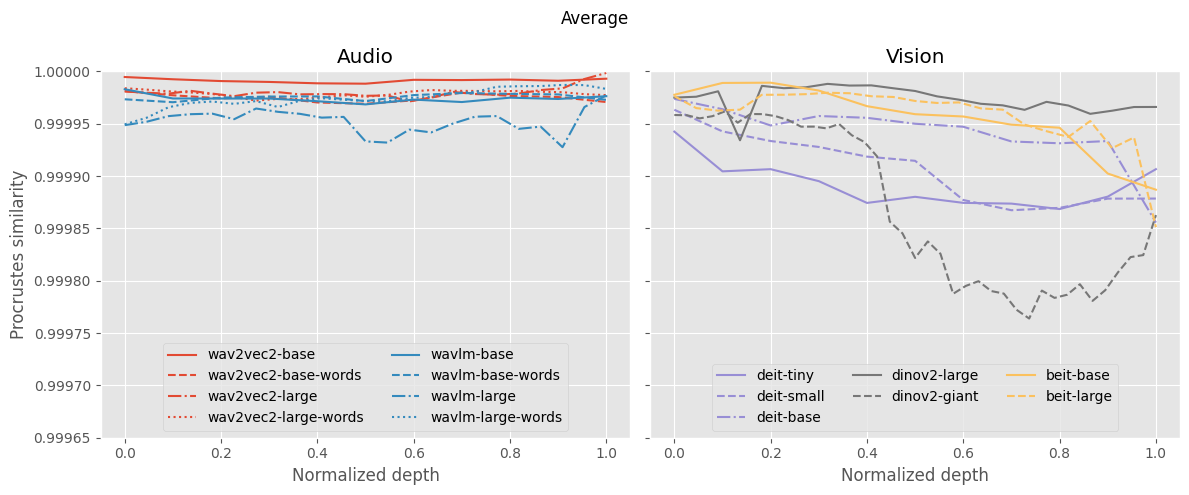

In [ ]:
EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments")

experiments = {
    'wav2vec2-base': EXP_PATH / "audio/wav2vec2-base/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'wav2vec2-base-words': EXP_PATH / "audio/wav2vec2-words/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'wav2vec2-large': EXP_PATH / "audio/wav2vec2-large/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'wav2vec2-large-words': EXP_PATH / "audio/wav2vec2-large-words/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'wavlm-base': EXP_PATH / "audio/wavlm-base/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'wavLM-base-words': EXP_PATH / "audio/wavLM-words/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'wavlm-large': EXP_PATH / "audio/wavlm-large/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'wavlm-large-words': EXP_PATH / "audio/wavlm-large-words/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    
    'deit-tiny': EXP_PATH / "vision/deit-tiny/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'deit-small': EXP_PATH / "vision/deit-small/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'deit-base': EXP_PATH / "vision/deit-base/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'dinov2-large': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'dinov2-giant': EXP_PATH / "vision/dinov2-giant-imagenet1k-1-layer/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'beit-base': EXP_PATH / "vision/beit-base/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'beit-large': EXP_PATH / "vision/beit-large/within=True_['procrustes-similarity']_start-iter=0_results.pth",

    # 'roberta-base': EXP_PATH / "text/roberta-base-go_emotions/within=True_['procrustes-similarity']_start-iter=0_results.pth",
}

previous_exp = ''
color_idx = -1
linestyle_idx = 0
linestyles = ['-', '--', '-.', ':']

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for exp_name, exp_path in experiments.items():
    exp_name = exp_name.lower()

    if exp_name.split("-")[0] in previous_exp:
        linestyle_idx += 1
    else:
        color_idx += 1
        linestyle_idx = 0

    if 'audio' in exp_path.as_posix():
        domain = 'audio'
        j = 0
    elif 'vision' in exp_path.as_posix():
        domain = 'vision'
        j = 1
    elif 'text' in exp_path.as_posix():
        domain = 'text'
        j = 2

    sims = torch.load(exp_path)
    sims = torch.tensor([sims['all-procrustes-similarities'][i]['between'] for i in range(50)])

    xaxis = torch.linspace(0, 1, len(sims.mean(dim=0)))
    # axs[j].plot(xaxis, sims.mean(dim=0), label=exp_name, color=f'C{color_idx}', linestyle=linestyles[linestyle_idx], marker='x')
    axs[j].plot(xaxis, sims.mean(dim=0), label=exp_name, color=f'C{color_idx}', linestyle=linestyles[linestyle_idx])
    # axs[j].fill_between(xaxis, sims.quantile(dim=0, q=0.05), sims.quantile(dim=0, q=0.95), alpha=0.2, color=f'C{color_idx}')
    axs[j].set_xlabel('Normalized depth')
    axs[j].set_title(domain.capitalize())
    previous_exp = exp_name

# axs[0].set_ylim(0.5, 1.1)
axs[0].legend(ncols=2, loc='lower center'); 
axs[1].legend(ncols=3, loc='lower center'); 
axs[1].set_ylim(0.99965, 1.)
# axs[2].legend()
axs[0].set_ylabel('Procrustes similarity')
fig.suptitle('Average')
plt.tight_layout()
plt.show()

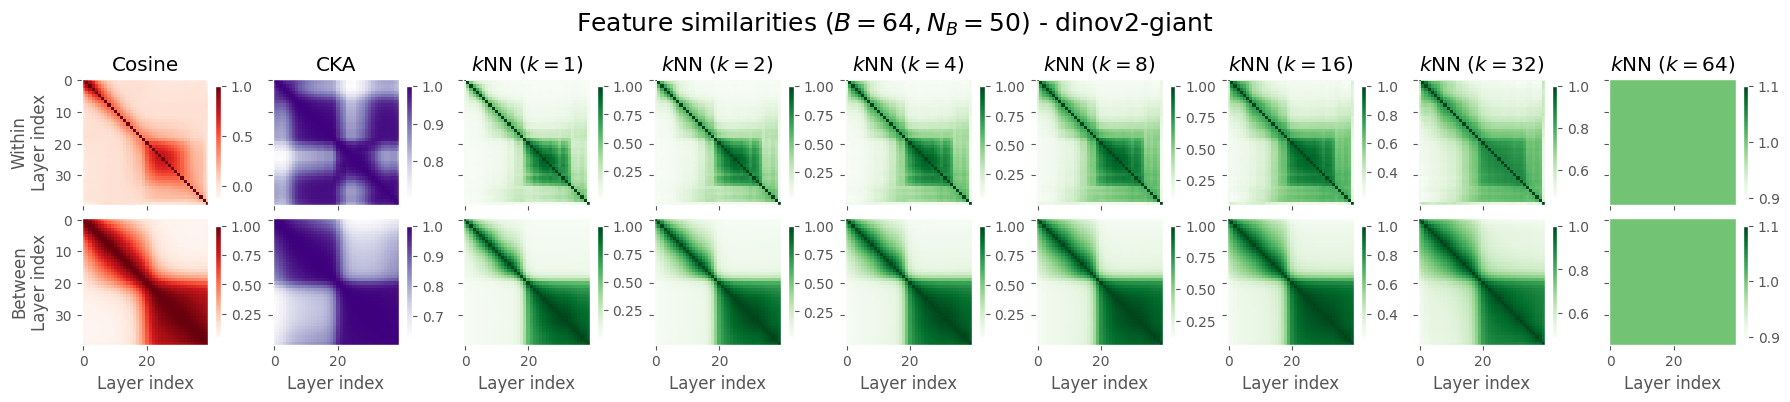

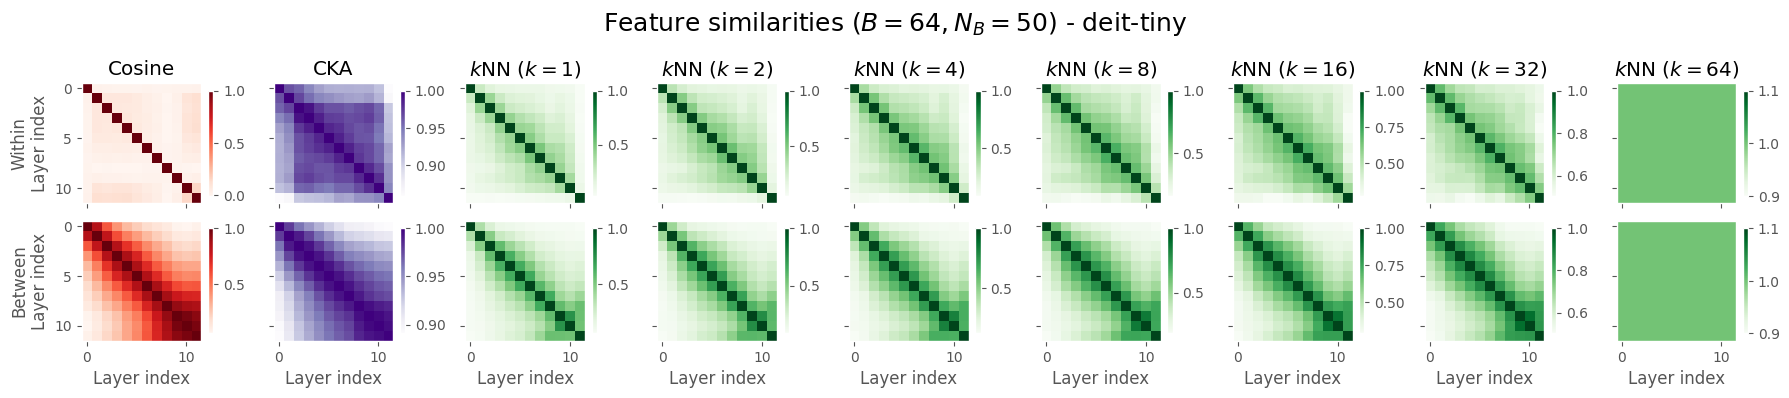

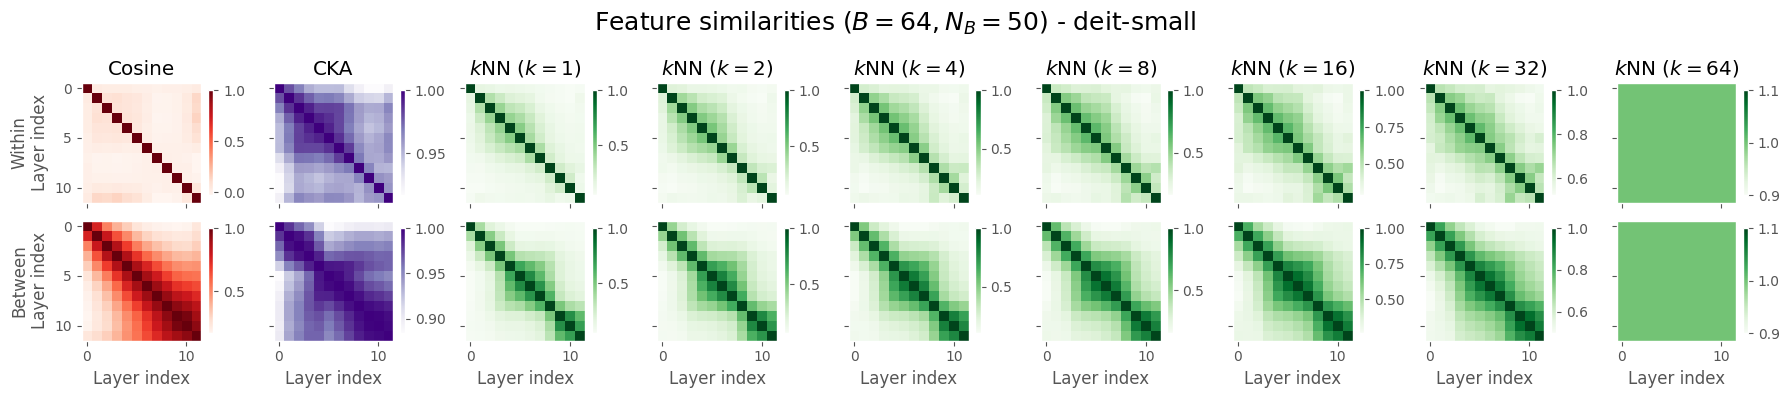

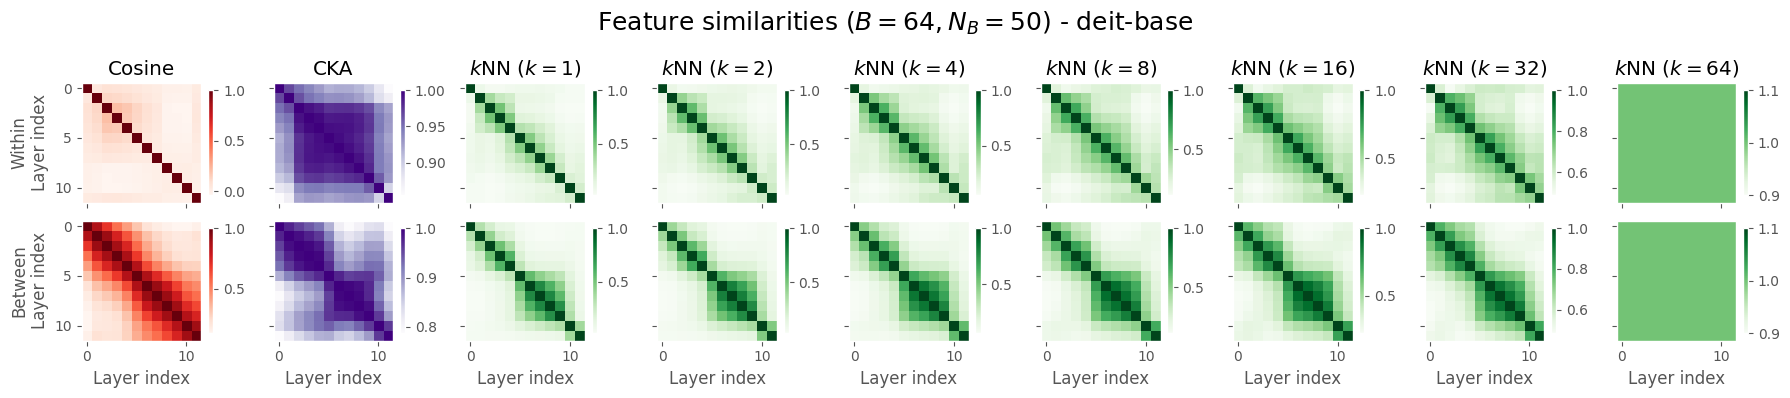

In [ ]:
EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/similarities")

experiments = {
    'dinov2-giant': EXP_PATH / "vision/dinov2-giant-imagenet1k-1-layer/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
    'deit-tiny': EXP_PATH / "vision/deit-tiny/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
    'deit-small': EXP_PATH / "vision/deit-small/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
    'deit-base': EXP_PATH / "vision/deit-base/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
}

for exp_name, exp_path in experiments.items():
    # Load results
    res = torch.load(exp_path)
    
    # Extract cosine similarities
    cos_within = torch.stack([elem['within'] for elem in res['all-cosine-similarities']])
    cos_between = torch.stack([elem['between'] for elem in res['all-cosine-similarities']])
    N_b = cos_within.shape[0]
    
    # Extract CKA similarities
    cka = torch.stack(res['all-cka-similarities'])
    cka_within = cka[:, ::2, ::2]
    cka_between = cka[:, 1::2, 1::2]

    # Extract mutual kNN similarities
    ks = res['all-mutual_knn-similarities']['within'][0].keys()
    mutual_knn_within = {k: torch.stack([res['all-mutual_knn-similarities']['within'][i][k] for i in range(N_b)]) for k in ks}
    mutual_knn_between = {k: torch.stack([res['all-mutual_knn-similarities']['between'][i][k] for i in range(N_b)]) for k in ks}

    fig, axs = plt.subplots(2, len(ks) + 2, figsize=(2*(len(ks) + 2), 4), sharex=True, sharey=True)
    
    # Plot cosine and CKA similarities
    plot_similarity_matrix(axs[0, 0], cos_within.mean(dim=0), 'cosine')
    plot_similarity_matrix(axs[1, 0], cos_between.mean(dim=0), 'cosine')
    axs[0, 0].set_title("Cosine")
    plot_similarity_matrix(axs[0, 1], cka_within.mean(dim=0), 'cka')
    plot_similarity_matrix(axs[1, 1], cka_between.mean(dim=0), 'cka')
    axs[0, 1].set_title('CKA')

    # Plot kNN similarities
    plot_knn_similarities(ks, mutual_knn_within, mutual_knn_between, exp_name, offset=2)

    axs[0, 0].set_ylabel("Within\nLayer index")
    axs[1, 0].set_ylabel("Between\nLayer index")
    axs[1, 0].set_xlabel('Layer index'); axs[1, 1].set_xlabel('Layer index')

    fig.suptitle(f"Feature similarities ($B={max(ks)}, N_B = {N_b}$) - {exp_name}", fontsize=18)
    plt.tight_layout()
    plt.show()

```
dinov2-giant (last - outside-in): 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 39 38 37 36 35 34 33 32 31 30 29 28 27 26 25 24 23 22 21 20 17 18 19 
dinov2-giant (first - outside-in): 19 18 17 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 39 38 37 36 35 34 33 32 31 30 29 28 27 26 25 24 23 22 21 20 

dinov2-giant (last - inside-out):  16 15 14 13 12 11 10 9 8 7 6 5 4 3 2 1 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 17 18 19 
dinov2-giant (first - inside-out): 19 18 17 16 15 14 13 12 11 10 9 8 7 6 5 4 3 2 1 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39
```

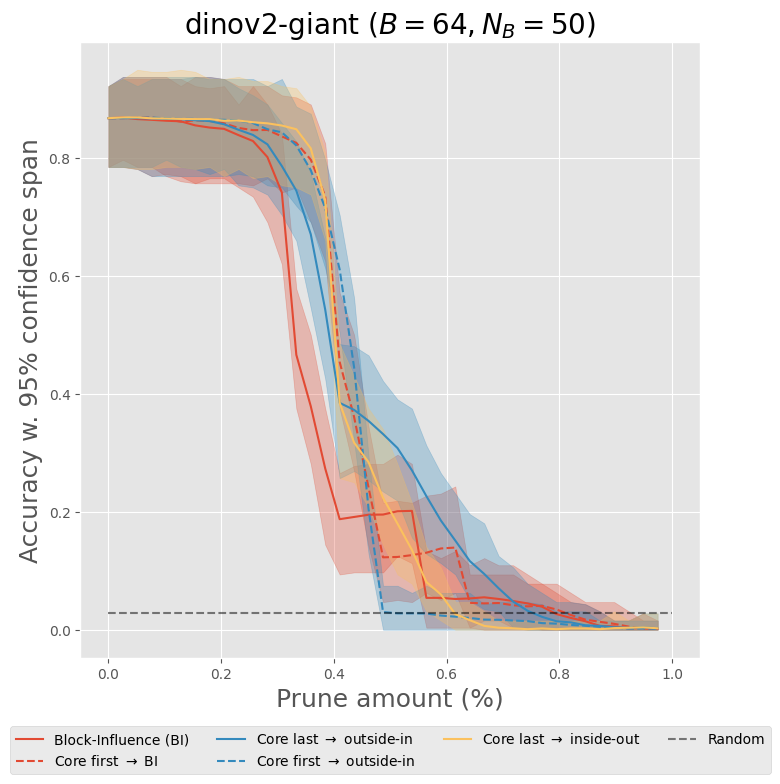

In [ ]:
EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/pruning")

num_classes = 35
_conf = 95
_alpha = round((1 - _conf / 100), 2)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

for a, a_name in enumerate(['outside-in-core-last', 'outside-in-core-first', 'inside-out-core-last']):#, 'inside-out-core-first']):
    ls = '-' if 'core-last' in a_name else '--'
    color = 'C4' if 'inside-out' in a_name else 'C1'
    name = f'Core {a_name.split("-")[-1]} $\\rightarrow$ {"-".join(a_name.split("-")[:2])}'
    all_results = {
        f'dinov2-giant': torch.load(EXP_PATH / a_name / f"vision/dinov2-giant-imagenet1k-1-layer/within=False_['pruning-performance']_start-iter=0_pruned-by=['block-influence']_results.pth"),
    }

    for i, (exp_name, results) in enumerate(all_results.items()):
        if a == 0:
            n_batches = results['accuracy']['block-influence'][0].__len__()
            batch_size = results['all-block-influences'][0].shape[0]
            num_layers = results['all-block-influences'][0].shape[1] + 1

            for strat_ in ['block-influence', 'core-first-block-influence']:
                mean_accs = {k: torch.tensor(v).mean().item() for k, v in results['accuracy'][strat_].items()}
                lower_accs = {k: torch.tensor(v).quantile(_alpha / 2).item() for k, v in results['accuracy'][strat_].items()}
                upper_accs = {k: torch.tensor(v).quantile(1 - _alpha / 2).item() for k, v in results['accuracy'][strat_].items()}

                xaxis = np.arange(len(mean_accs.keys())) / len(mean_accs.keys())
                ax.fill_between(xaxis, list(lower_accs.values()), list(upper_accs.values()), alpha=0.3, color='C0')
                ax.plot(xaxis, list(mean_accs.values()), label='Core first $\\rightarrow$ BI' if 'core' in strat_ else '$k$NN' if 'knn' in strat_ else 'Block-Influence (BI)', linestyle='--' if 'core' in strat_ else '-', color='C0' if 'knn' not in strat_ else 'C3')
                
        pruning_strategy = 'custom'
        mean_accs = {k: torch.tensor(v).mean().item() for k, v in results['accuracy'][pruning_strategy].items()}
        lower_accs = {k: torch.tensor(v).quantile(_alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
        upper_accs = {k: torch.tensor(v).quantile(1 - _alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
        
        xaxis = np.arange(len(mean_accs.keys())) / len(mean_accs.keys())
        ax.fill_between(xaxis, list(lower_accs.values()), list(upper_accs.values()), alpha=0.3, color=color)
        ax.plot(xaxis, list(mean_accs.values()), label=name if pruning_strategy == 'custom' else pruning_strategy, linestyle=ls, color=color)
        ax.set_xlabel('Prune amount (%)', fontsize=18)
        ax.set_title(f'{exp_name} ($B = {batch_size}, N_B = {n_batches}$)', fontsize=20)

ax.set_ylabel(f'Accuracy w. {_conf}% confidence span', fontsize=18)
ax.hlines(1/num_classes, xmin=0, xmax=1, color='black', linestyle='--', alpha=0.5, label='Random')

# ax.legend(fontsize=18, bbox_to_anchor=(1.1, -1.35), loc='upper center', ncols=4)
ax.legend(ncols=4, loc='lower center', bbox_to_anchor=(0.5, -0.2))
plt.show()

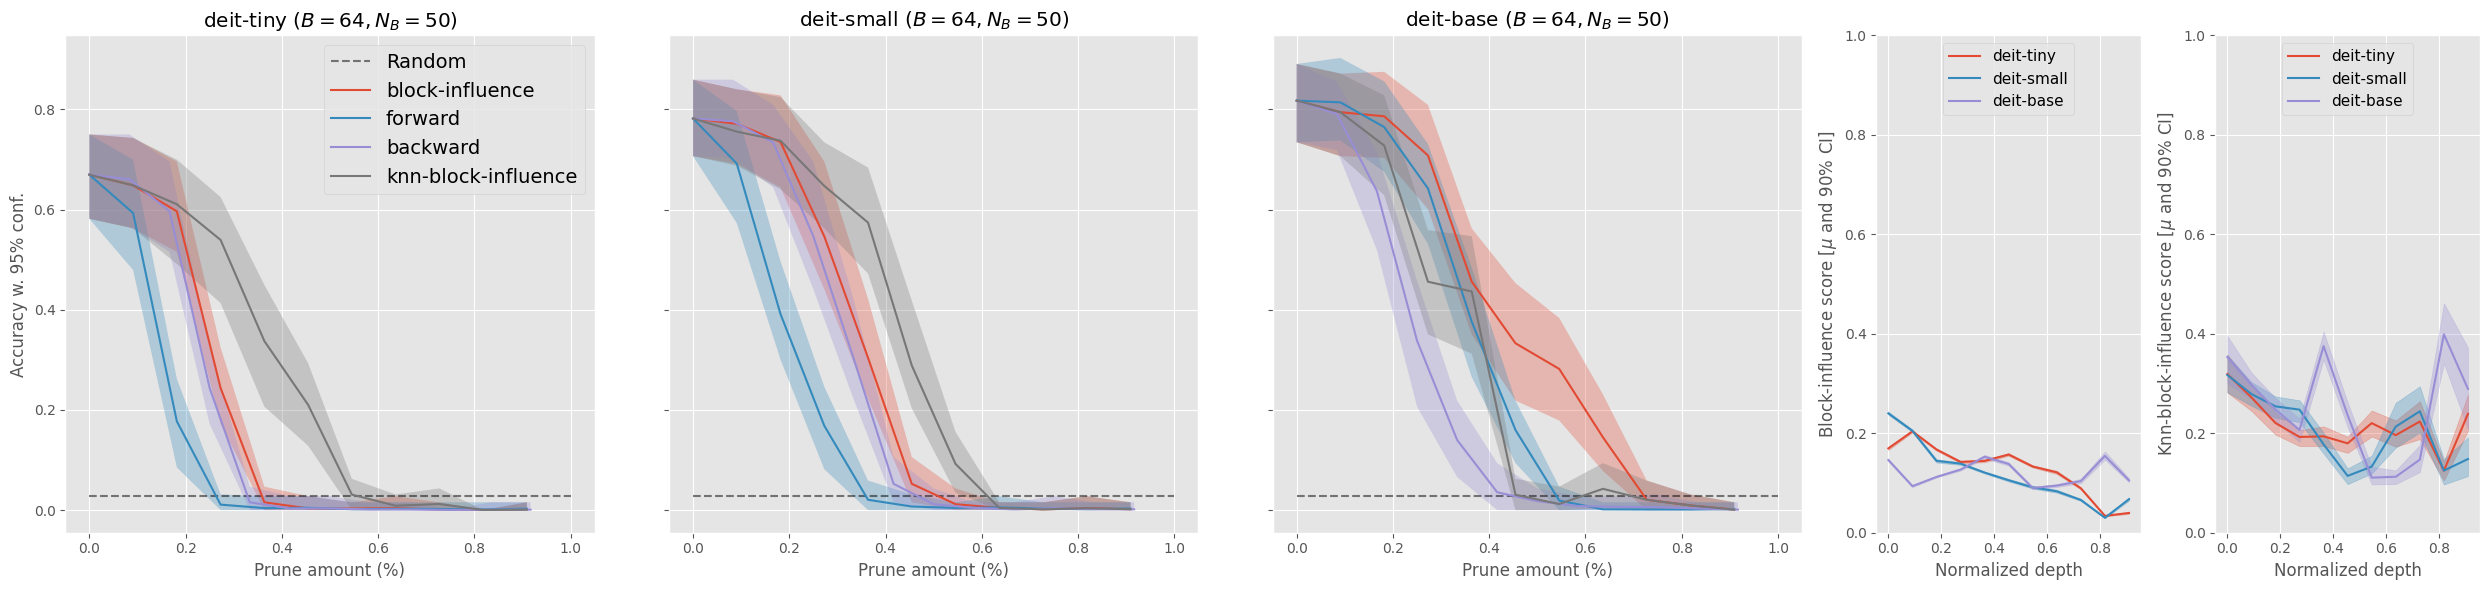

In [ ]:
num_classes = 35
_conf = 95
_alpha = round((1 - _conf / 100), 2)

EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/pruning/adaptive")

fig, axs = plt.subplots(1, 3+2, figsize=(5*(3+2), 6), sharey=True, gridspec_kw={'width_ratios': [1, 1, 1, 0.5, 0.5]}, sharex='col', squeeze=False)

_row = 0
all_results = {
    f'deit-tiny': torch.load(EXP_PATH / f"vision/deit-tiny/bs64_50iter_results.pth"),
    f'deit-small': torch.load(EXP_PATH / f"vision/deit-small/bs64_50iter_results.pth"),
    f'deit-base': torch.load(EXP_PATH / f"vision/deit-base/bs64_50iter_results.pth"),
}
for i, (exp_name, results) in enumerate(all_results.items()):
    n_batches = results['accuracy']['forward'][0].__len__()
    batch_size = results['all-block-influences'][0].shape[0]
    num_layers = results['all-block-influences'][0].shape[1] + 1

    axs[_row, i].hlines(1/num_classes, xmin=0, xmax=1, color='black', linestyle='--', alpha=0.5, label='Random')

    for pruning_strategy in ['block-influence', 'forward', 'backward', 'knn-block-influence']:
        mean_accs = {k: torch.tensor(v).mean().item() for k, v in results['accuracy'][pruning_strategy].items()}
        lower_accs = {k: torch.tensor(v).quantile(_alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
        upper_accs = {k: torch.tensor(v).quantile(1 - _alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}

        xaxis = np.arange(len(mean_accs.keys())) / len(mean_accs.keys())
        axs[_row, i].fill_between(xaxis, list(lower_accs.values()), list(upper_accs.values()), alpha=0.3)
        axs[_row, i].plot(xaxis, list(mean_accs.values()), label=pruning_strategy)

    axs[_row, i].set(xlabel='Prune amount (%)', title=f'{exp_name} ($B = {batch_size}, N_B = {n_batches}$)')
    # axs[_row, i].set_xticks(range(num_layers)[::num_layers // 10], range(num_layers)[::num_layers // 10])
axs[_row, 0].set(ylabel=f'Accuracy w. {_conf}% conf.')

axs[0, 0].legend(loc='upper right', fontsize=14)

# Plot block influence scores
experiments = {
    f'deit-tiny': EXP_PATH / f"vision/deit-tiny/bs64_50iter_results.pth",
    f'deit-small': EXP_PATH / f"vision/deit-small/bs64_50iter_results.pth",
    f'deit-base': EXP_PATH / f"vision/deit-base/bs64_50iter_results.pth",
}

for _ax_idx in [3, 4]:
    gs = axs[0, 2].get_gridspec()
    # remove the underlying Axes
    for ax in axs[0:, _ax_idx]:
        ax.remove()
    axbig = fig.add_subplot(gs[0:, _ax_idx])
    plot_heuristic(experiments, axbig, res_per_exp=1, relative_layer_idx=True, heuristic='block-influence' if _ax_idx == 3 else 'knn-block-influence')
    axbig.set_ylim(0., 1.)
    axbig.legend(loc='upper center', fontsize=11)

plt.tight_layout()
plt.show()